# 📓 Cas d'usage IA — Orientation et tri multimodal des demandeurs d'emploi

**Auteur·e** : `Franck BEUGNET`  
**Promo** : ATOS Atlas IA — Parcours 2 (Pros IT)  
**Date début** : `15/06/2026`  
**Dernière mise à jour** : `30/09/2026`

**Repository Git associé** : https://github.com/FranckBeugnet/certification_upskilling_ia

---

## 0. Imports & configuration


In [23]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Affichage
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")


## 0.5 Traçabilité de la session

In [4]:
import sys
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "Trajectoire et Retour à l'Emploi"
DATASET_SOURCE = "Extraction SI Agence Nationale pour l'Emploi (Données historiques)"
DATASET_VERSION = "2026-07-09 (v1.0.0)"

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")


Date session : 2026-09-23T09:51
Python       : 3.14.6
NumPy        : 2.5.3
Pandas       : 3.0.5
Git commit   : 3dedde1
Dataset      : Trajectoire et Retour à l'Emploi (source=Extraction SI Agence Nationale pour l'Emploi (Données historiques), version=2026-07-09 (v1.0.0))


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

**Le Client :** L'Agence nationale de l'emploi.

**Le Problème :** L'agence gère un flux massif de demandeurs d'emploi. Pour optimiser l'accompagnement et cibler les ressources là où elles sont le plus nécessaires, les conseillers ont besoin d'identifier rapidement le délai potentiel de retour à l'emploi de chaque usager.

**La Solution IA :** Un outil d'aide à la décision (système expert d'aiguillage) qui analyse non seulement les données administratives classiques (âge, diplôme, géographie) mais aussi le texte libre saisi par le conseiller lors du premier entretien. L'IA doit soulager le conseiller du tri initial pour qu'il puisse se concentrer sur l'accompagnement humain.

### 1.2 Énoncé du problème IA

D'un point de vue technique, nous sommes face à une **Tâche supervisée de classification multiclasse à 3 classes**.
* **Supervisée** : Car nous avons un jeu de données historique où la "réponse" (la classe réelle) est connue pour chaque demandeur (2500 échantillons).
* **Classification** : Car nous ne cherchons pas à prédire un chiffre continu (ex: le nombre exact de jours), mais une catégorie.
* **Les 3 classes** :
  - `0` : Rapide (< 6 mois)
  - `1` : Moyen (entre 6 et 12 mois)
  - `2` : Risque de longue durée (> 12 mois)

*Particularité technique :* C'est une IA **multimodale** car elle ingère deux types de données très différents : du tabulaire structuré (chiffres/catégories) et du texte non structuré (NLP).

### 1.3 Bénéficiaires & impacts

- **Directs (les utilisateurs) :** Les conseillers de l'agence. L'outil leur fait gagner du temps et objective leurs ressentis.
- **Indirects (les sujets) :** Les demandeurs d'emploi. L'IA influence la priorité avec laquelle leur dossier sera traité.
- **L'Impact Métier (Le point critique) :** En IA, toutes les erreurs ne se valent pas. Si le modèle prédit un retour Rapide (Classe 0) pour un usager qui, en réalité, est en Risque de longue durée (Classe 2), c'est un **Faux Négatif grave**. L'usager ne recevra pas l'accompagnement renforcé dont il a besoin, entraînant un préjudice humain (détresse) et financier (coût social). À l'inverse, prédire "Risque" pour quelqu'un de "Rapide" (Faux Positif) est moins grave, cela coûte juste un peu de temps au conseiller. Notre modèle devra donc être pénalisé fortement sur ces erreurs critiques.

### 1.4 Critères de succès

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | Minimisation des erreurs critiques | Proche de 0% de Faux Négatifs sur la classe 2 | Recall Classe 2 > 60% | Atteindre 0% de FN détruirait la précision globale (trop de fausses alertes). Un Recall > 60% garantit la détection de près de 2 dossiers à risque sur 3 . Les cas les plus incertains seront gérés par le filet de sécurité humain (HITL). |
| Modèle | Métrique robuste au déséquilibre | F1-score macro ≥ 0.75 | F1-score macro > 0.60 | La cible théorique sans contrainte était de 0.70. Cependant, par anticipation des contraintes éthiques de l'AI Act (Privacy by Design), une baisse de performance jusqu'à 0.60 sera tolérée si le modèle final garantit l'absence de variables discriminatoires (âge, origine). Le F1-score macro force le modèle à ne pas ignorer la classe minoritaire. |
| Opérationnel | Temps de réponse API | < 500 ms | < 1000 ms | Le conseiller doit avoir la réponse en temps réel pendant son face-à-face avec l'usager. |

### 1.5 Risques éthiques & réglementaires anticipés

Une IA dans le service public soulève des enjeux réglementaires majeurs :
1. **Risque de Discrimination algorithmique (Biais) :** Notre jeu de données contient des variables sensibles. L'`age` (risque d'âgisme) et la `nationalité_hors_ue` (risque de xénophobie). Si le modèle apprend que ces caractéristiques allongent mathématiquement le délai de retour à l'emploi, il pourrait systématiquement défavoriser ces profils, violant ainsi la *Loi pour une République Numérique*. Nous devrons mesurer ce biais (ex: calcul du Disparate Impact).
2. **RGPD (Protection des données) :** La variable `synthese_entretien` est un texte libre. Il est très probable qu'elle contienne des PII (Personally Identifiable Information) comme des noms, des adresses ou des données de santé. Une anonymisation ou une vigilance stricte sera requise.
3. **Transparence et Responsabilité (AI Act) :** L'IA ne doit faire que des *recommandations*. C'est le conseiller qui garde la décision finale d'orientation (Principe du *Human-In-The-Loop* ou HITL). Le modèle se doit donc d'être explicable.

### 1.6 Synthèse cadrage

Nous allons concevoir un classifieur multiclasse multimodal dont le succès ne se mesurera pas uniquement à sa précision mathématique globale, mais à sa capacité à **minimiser les erreurs asymétriques** (ne rater aucun profil à risque) tout en **garantissant l'équité algorithmique** sur les populations sensibles (âge, origine).

---
## 2. Identification & acquisition des données

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| Fournie par l'agence | Extract SI | 2500 lignes | CSV | Local | Juil 2026 |


In [5]:
# 2.2 Chargement
import hashlib
DATA_DIR = Path("data")
file_path = DATA_DIR / "dataset_trajectoire_emploi.csv"
print("Hash MD5:", hashlib.md5(file_path.read_bytes()).hexdigest())

df = pd.read_csv(file_path)
df.shape, df.columns.tolist()

Hash MD5: 2605ca4999428fa1a7d25bd00f17eb0a


((2500, 10),
 ['usager_id',
  'age',
  'niveau_diplome',
  'anciennete_poste_ans',
  'code_rome_vise',
  'code_insee_commune',
  'est_allocataire',
  'nationalite_hors_ue',
  'synthese_entretien',
  'classe_retour_emploi'])

### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Statut éthique / RGPD |
|---|---|---|---|---|---|
| `usager_id` | Identifiant unique | ID | | ❌ | Donnée personnelle ordinaire (anonymisée) |
| `age` | Âge de l'usager (en années) | Numérique | | ❌ | ⚠️ Facteur de discrimination potentielle (âgisme) |
| `niveau_diplome` | Plus haut diplôme obtenu | Catégoriel | Sans diplôme, Bac, Bac+2, Bac+5 | ❌ | Donnée personnelle ordinaire |
| `anciennete_poste_ans`| Expérience dans le dernier emploi (en années) | Numérique | | ❌ | Donnée professionnelle ordinaire |
| `code_rome_vise` | Code emploi ROME (5 chars) | Catégoriel | | ❌ | Donnée professionnelle ordinaire |
| `code_insee_commune` | Code géo INSEE | Catégoriel | | ❌ | ⚠️ Proxy géographique potentiel |
| `est_allocataire` | Statut d'indemnisation | Booléen | 0, 1 | ❌ | Donnée administrative ordinaire |
| `nationalite_hors_ue` | Origine hors UE | Booléen | 0, 1 | ❌ | ⚠️ Facteur de discrimination potentielle (origine) |
| `synthese_entretien` | Notes textuelles du conseiller | Texte | | ❌ | ⚠️ Texte libre (risque de PII / données sensibles Art. 9) |
| `classe_retour_emploi`| Délai de retour à l'emploi | Cible (0,1,2) | 0: <6m, 1: 6-12m, 2: >12m | ✅ | Donnée d'évaluation métier |

> 💡 **Précision juridique (RGPD vs Anti-discrimination) :**
> * Au sens strict de l'**Article 9 du RGPD**, les « données sensibles » (catégories particulières) concernent l'origine raciale ou ethnique, les opinions politiques, convictions religieuses, données de santé, biométriques, etc. L'**âge** et la **nationalité** sont juridiquement des **données personnelles ordinaires**, non des données sensibles Art. 9.
> * En revanche, au regard du **droit de la non-discrimination** et des exigences de l'**AI Act** sur les systèmes à haut risque, l'âge et la nationalité constituent des critères protégés majeurs présentant un risque fort de discrimination algorithmique (âgisme, préférence nationale).

> **Le Code ROME** : Le Répertoire Opérationnel des Métiers et des Emplois (ROME) est la nomenclature utilisée par France Travail pour classer les métiers. Il est composé d'une lettre (grande famille) et de 4 chiffres. C'est une information clé mais à forte cardinalité.

### 2.5 Synthèse acquisition

Jeu de données hybride de 2500 échantillons avec présence de variables à risque discriminatoire (`nationalite_hors_ue`, `age`) et d'un champ texte libre susceptible de contenir des PII (`synthese_entretien`). Une vigilance sera apportée sur les valeurs manquantes (ex: `niveau_diplome`).

**Conformité Éthique** : Des mesures techniques spécifiques (comme le calcul du *Disparate Impact*) devront être implémentées sur ces variables à risque afin de prévenir et mitiger tout biais algorithmique (en accord avec l'AI Act).

### 2.4 Datasheet du Dataset (selon Gebru et al., 2018)

> 📄 **Datasheet complète disponible :** [data/DATASHEET.md](data/DATASHEET.md)

Conformément aux recommandations de **Gebru et al. (2018)** (*Datasheets for Datasets*), une fiche technique complète à destination du DPO, des équipes métier et de la gouvernance IA a été rédigée et est maintenue directement aux côtés du jeu de données : [data/DATASHEET.md](data/DATASHEET.md).

Elle synthétise en 7 sections :
1. **Motivation** : Contexte d'orientation des demandeurs d'emploi et exigences AI Act.
2. **Composition** : 2 500 lignes, 10 colonnes, signalement des variables sensibles (`age`, `nationalite_hors_ue`, `synthese_entretien` PII).
3. **Processus de collecte** : Biais de sélection et historiques.
4. **Préprocessing appliqué** : Imputation, encodages (OHE / Ordinal), TF-IDF NLP et scénario S2 (Éthique).
5. **Usages prévus / à éviter** : Aide à la décision avec supervision humaine (HITL) vs interdiction d'automatisation à 100%.
6. **Distribution** : Accès contrôlé interne.
7. **Maintenance** : Versioning v1.0.0 (Franck BEUGNET).


---
## 3. Exploration & analyse des données (EDA)

In [6]:
# 0. Chargement des données
df = pd.read_csv('data/dataset_trajectoire_emploi.csv')


# 1 Premier coup d'œil
display(df.head())
print("\n--- INFORMATIONS GENERALES ---")
df.info()
print("\n--- DESCRIPTION STATISTIQUE ---")
display(df.describe(include='all'))

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0



--- INFORMATIONS GENERALES ---
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   str    
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   str    
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   str    
 5   code_insee_commune    2500 non-null   str    
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   str    
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), str(5)
memory usage: 195.4 KB

--- DESCRIPTION STATISTIQUE ---


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
count,2500,2378.000000,2416,2500.000000,2500,2500,2456.000000,2500.000000,2419,2500.000000
unique,2500,NaN,4,NaN,50,2407,NaN,NaN,9,NaN
top,ID_0000,NaN,Bac,NaN,H1206,46283,NaN,NaN,Compétences à réactualiser sur les outils numé...,NaN
freq,1,NaN,966,NaN,71,3,NaN,NaN,338,NaN
mean,NaN,40.566442,NaN,2.971600,NaN,NaN,0.595684,0.118000,NaN,0.806400
std,NaN,13.225242,NaN,2.979548,NaN,NaN,0.490859,0.322673,NaN,0.719671
min,NaN,18.000000,NaN,0.000000,NaN,NaN,0.000000,0.000000,NaN,0.000000
25%,NaN,29.000000,NaN,0.800000,NaN,NaN,0.000000,0.000000,NaN,0.000000
50%,NaN,41.000000,NaN,2.000000,NaN,NaN,1.000000,0.000000,NaN,1.000000
75%,NaN,52.000000,NaN,4.100000,NaN,NaN,1.000000,0.000000,NaN,1.000000


> **Analyse de l'aperçu** : 
>
>Le jeu de données contient 2500 lignes. 
>
>On observe un mélange de variables numériques (`age`, `anciennete_poste_ans`) et de chaînes de caractères (`niveau_diplome`, `synthese_entretien`). 
>
>Le format est adapté à un traitement classique, mais il faudra impérativement encoder les variables catégorielles avant de les passer à un modèle ML.


### 3.1 Analyse de la distribution de la variable cible (Déséquilibre)

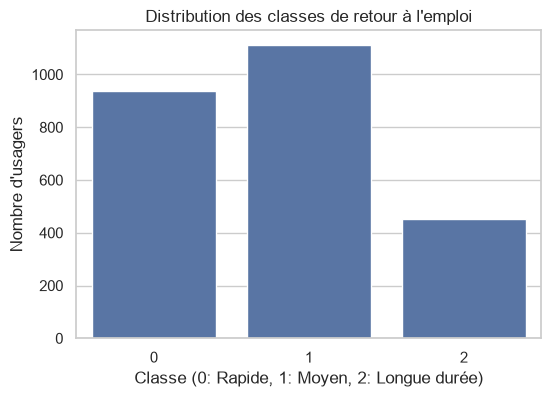

In [7]:
# 2. Distribution de la variable cible (Déséquilibre)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='classe_retour_emploi')
plt.title('Distribution des classes de retour à l\'emploi')
plt.xlabel('Classe (0: Rapide, 1: Moyen, 2: Longue durée)')
plt.ylabel('Nombre d\'usagers')
plt.show()



>  **Analyse de la cible** : 
>
>On constate un déséquilibre évident.
>
>La classe 1 (Moyen) est majoritaire (44%), la classe 0 (Rapide) représente 37%, et la classe 2 (Risque longue durée) est minoritaire à 18%.  
>
> **Action pour la suite** : 
>
>Ce déséquilibre est dangereux car un modèle pourrait ignorer la classe 2 (pourtant la plus critique d'un point de vue métier) au profit de la précision globale (Accuracy). Nous devrons utiliser l'argument `class_weight='balanced'` lors de l'entraînement, ou générer des données synthétiques via SMOTE.

### 3.2 Analyse de la qualité des données

--- VALEURS MANQUANTES ---
age                   122
niveau_diplome         84
est_allocataire        44
synthese_entretien     81
dtype: int64

--- DOUBLONS ---
Nombre de doublons exacts : 0


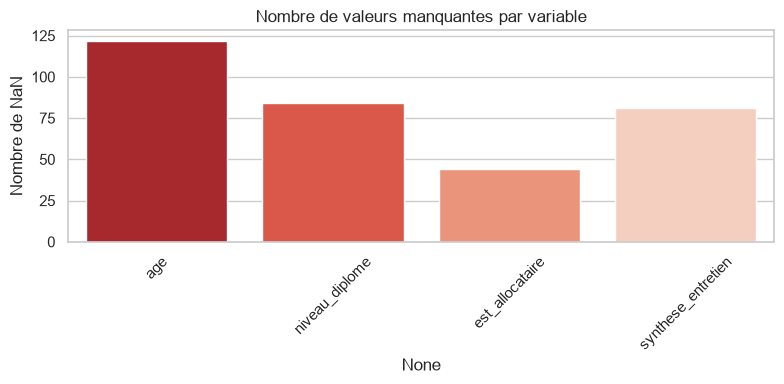

In [8]:
# 3 Qualité des données : manquants, doublons, valeurs aberrantes
print("--- VALEURS MANQUANTES ---")
print(df.isna().sum()[df.isna().sum() > 0])
print("\n--- DOUBLONS ---")
print(f"Nombre de doublons exacts : {df.duplicated().sum()}")

# Visualisation graphique des valeurs manquantes
df_na = df.isna().sum()
df_na = df_na[df_na > 0]
if not df_na.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=df_na.index, y=df_na.values, hue=df_na.index, legend=False, palette='Reds_r')
    plt.title('Nombre de valeurs manquantes par variable')
    plt.xticks(rotation=45)
    plt.ylabel('Nombre de NaN')
    plt.tight_layout()
    plt.show()


> **Constat sur la qualité** : 
>
>Il n'y a aucun doublon parfait, ce qui est une bonne nouvelle. En revanche, nous avons des valeurs manquantes critiques, notamment sur l'`age` (122), le `niveau_diplome` (84), `est_allocataire` (44) et la `synthese_entretien` (81).  
>
> **Action pour la suite** : 
>
>Dans la section 4 (Préparation), il faudra construire des transformateurs (`SimpleImputer`) pour combler ces trous (ex: médiane pour l'âge, valeur 'Inconnu' pour le diplôme) afin de ne pas perdre ces observations.
>
> **Conséquences de l'imputation (vs Suppression) :**
>
> **Points positifs (Pourquoi on le fait) :**
> - **Conservation de l'information** : Supprimer toutes les lignes incomplètes nous ferait perdre ~10% du jeu de données. Même sans l'âge ou le diplôme, la synthèse d'entretien (texte) reste cruciale.
> - **Robustesse en production** : Si un conseiller oublie de saisir l'âge dans l'outil final, le modèle (et l'API) doit savoir réagir sans planter. L'imputation l'y prépare.
>
> **Points d'attention (Les risques à maîtriser) :**
> - **Biais de distribution (Âge médian)** : Remplacer 122 âges par la médiane (41 ans) crée un pic artificiel qui réduit la variance globale de la variable.
> - **Création d'une modalité artificielle (Diplôme 'Inconnu')** : Le modèle pourrait apprendre que le fait de 'ne pas avoir renseigné l'information' est un facteur de risque en soi.
> 
> **Alternative avancée** : Au lieu d'une médiane, un **KNNImputer** permettrait de déduire l'âge en se basant sur des profils similaires. Nous conserverons la médiane comme *baseline* initiale.


### 3.3 Analyse des distributions

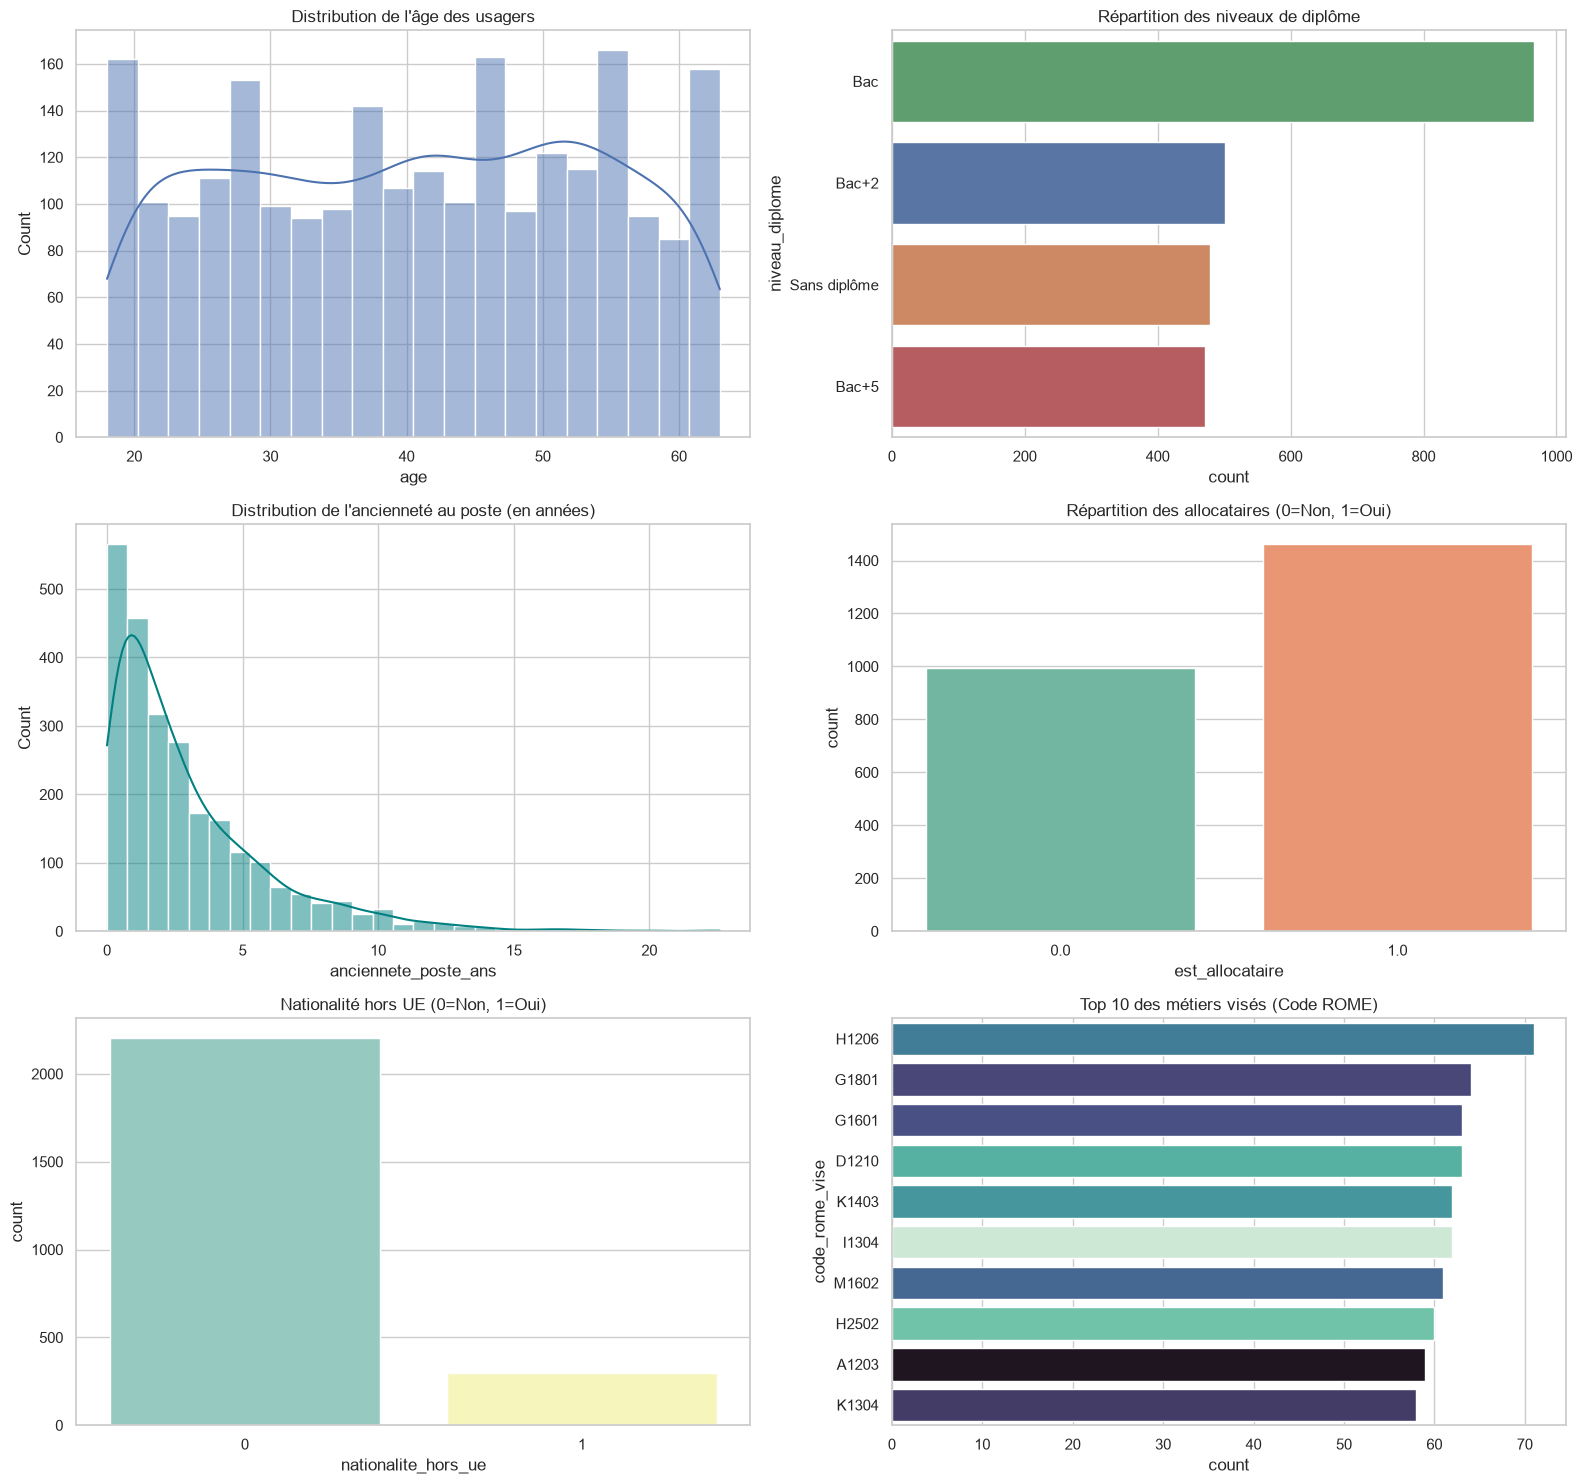

In [9]:
# 4 Distribution des variables
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 1. Distribution de l'âge
sns.histplot(data=df, x='age', bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution de l\'âge des usagers')

# 2. Distribution des niveaux de diplôme
sns.countplot(data=df, y='niveau_diplome', hue='niveau_diplome', legend=False, order=df['niveau_diplome'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Répartition des niveaux de diplôme')

# 3. Ancienneté au poste
sns.histplot(data=df, x='anciennete_poste_ans', bins=30, kde=True, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Distribution de l\'ancienneté au poste (en années)')

# 4. Statut Allocataire
sns.countplot(data=df, x='est_allocataire', hue='est_allocataire', legend=False, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Répartition des allocataires (0=Non, 1=Oui)')

# 5. Nationalité hors UE
sns.countplot(data=df, x='nationalite_hors_ue', hue='nationalite_hors_ue', legend=False, ax=axes[2, 0], palette='Set3')
axes[2, 0].set_title('Nationalité hors UE (0=Non, 1=Oui)')

# 6. Top 10 des codes ROME (Métiers visés)
top_romes = df['code_rome_vise'].value_counts().nlargest(10).index
sns.countplot(data=df, y='code_rome_vise', hue='code_rome_vise', legend=False, order=top_romes, ax=axes[2, 1], palette='mako')
axes[2, 1].set_title('Top 10 des métiers visés (Code ROME)')

plt.tight_layout()
plt.show()


> **Analyse des distributions (pour les néophytes)** :  
> - **Âge** : Suit une distribution proche d'une courbe en cloche (loi normale), centrée autour de 40 ans (18 à 63 ans). Aucune valeur aberrante bloquante n'est détectée.  
> - **Diplôme** : Les niveaux 'Bac' et 'Bac+2' sont fortement majoritaires.  
> - **Ancienneté au poste** : On observe une forme "écrasée" sur la gauche (très peu de personnes ont une grande ancienneté, la majorité est en dessous de 5 ans). La distribution est asymétrique. Il faudra probablement la transformer (ex: log-transformation) pour aider certains modèles à mieux la digérer.
> - **Statuts (Allocataire et Nationalité)** : Les allocataires sont une courte majorité. Pour la nationalité, la grande majorité est Européenne (0). Cette donnée "Nationalité hors UE" est rare (11%) et de surcroît sensible éthiquement.
> - **Les métiers visés (Code ROME)** : Le graphique nous montre seulement les 10 métiers les plus demandés, mais en réalité notre base contient 50 métiers différents ! C'est ce qu'on appelle une donnée à "forte cardinalité".
> - **Le cas des communes (Code INSEE)** : Non tracé ici car il y a **2407 communes différentes** pour 2500 usagers. Un graphique avec 2407 barres serait illisible.
> 
> **Action pour la suite (Préparation des données)** :  
> 
> **Action sur l'Âge (Standardisation)** :  
> - **Quoi ?** Une standardisation (via `StandardScaler`) sera intégrée au pipeline de préparation.  
> - **Pourquoi ?** L'âge s'exprime sur une échelle (18-63) bien plus grande que nos variables booléennes (0/1). Sans standardisation, des algorithmes basés sur les distances (ex: Régression Logistique, SVM) accorderaient un poids démesuré à l'âge. Bien que facultative pour les modèles basés sur des arbres (Random Forest), c'est une excellente pratique (*Clean Code*) pour comparer équitablement divers algorithmes.
> 
> **Action sur le Diplôme (Encodage Ordinal)** :  
> - **Quoi ?** Un encodage préservant la hiérarchie (via `OrdinalEncoder`) sera appliqué au lieu d'un simple `OneHotEncoder`.  
> - **Pourquoi ?** Les algorithmes nécessitent des entrées numériques. Le niveau de diplôme possédant un ordre naturel (Sans diplôme < Bac < Bac+2 < Bac+5), un encodage ordinal permet au modèle (surtout les arbres de décision) de capter et d'exploiter cette notion de progression scolaire, au lieu de traiter chaque niveau de manière totalement isolée.
> 
> **Action sur l'Ancienneté (Transformation mathématique)** :
> - **Quoi ?** Une transformation de type logarithmique ou *Power Transform*.
> - **Pourquoi ?** A cause de son asymétrie, certains modèles peineront à modéliser la minorité de profils très anciens. La transformation ramènera la distribution vers une forme de courbe en cloche plus "normale".
> 
> **Action sur les Codes ROME et INSEE (Feature Engineering)** :
> - **Quoi ?** Regroupement par grandes familles (ex: première lettre du Code ROME) ou remplacement par des variables "macro" (ex: taux de chômage du Code INSEE de la commune via de la donnée externe).
> - **Pourquoi ?** Si l'on donne ces variables brutes, l'algorithme va les apprendre par cœur (sur-apprentissage) au lieu d'en déduire une logique globale, ce qui nuira gravement à ses performances sur de nouveaux profils.


### 3.4 Analyse des corrélations & relations entre variables

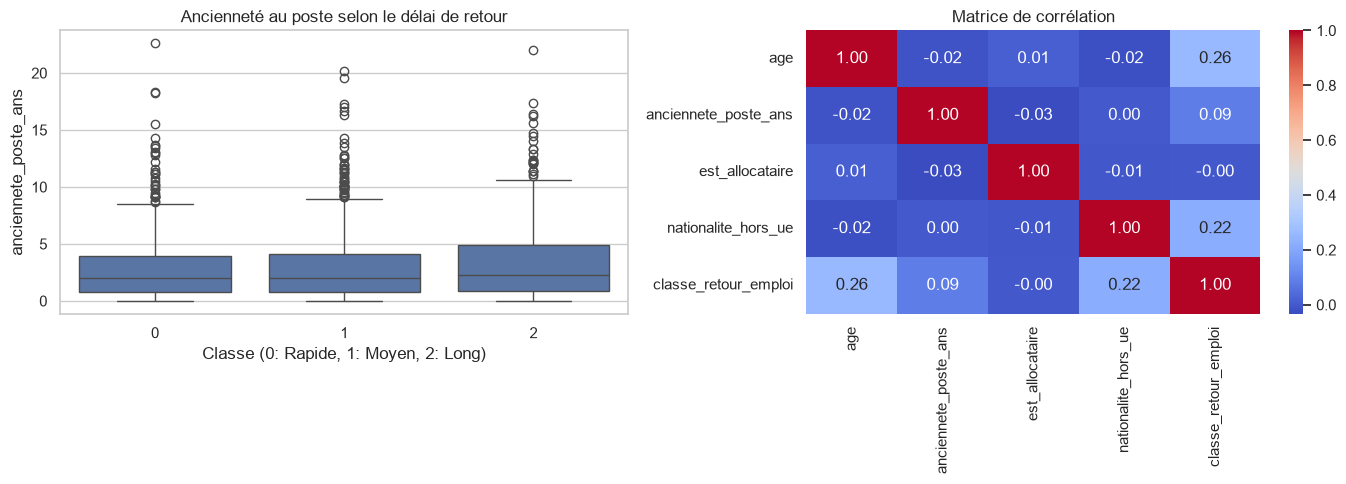

In [10]:
# 5 Corrélations & relations entre variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Relation Ancienneté Poste vs Classe retour emploi
sns.boxplot(data=df, x='classe_retour_emploi', y='anciennete_poste_ans', ax=axes[0])
axes[0].set_title('Ancienneté au poste selon le délai de retour')
axes[0].set_xlabel('Classe (0: Rapide, 1: Moyen, 2: Long)')

# Matrice de corrélation (sur les variables numériques)
num_cols = df.select_dtypes(include=['number']).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Matrice de corrélation')

plt.tight_layout()
plt.show()

> **Analyse des relations (explication pour les néophytes)** :  
> - **Qu'est-ce qu'une corrélation ?** C'est un indicateur qui mesure si deux données évoluent ensemble. Par exemple, si l'ancienneté augmente mécaniquement avec l'âge, on dit qu'ils sont positivement corrélés.
> - **Lecture du graphique (Heatmap)** : Ce tableau coloré croise toutes nos données chiffrées. Une couleur rouge vif indique un lien fort et direct (quand l'un monte, l'autre monte), tandis qu'un bleu foncé indique un lien inverse. Si les couleurs sont pâles (chiffres proches de 0), cela signifie qu'il n'y a pas de lien évident et "simple" (comme une ligne droite).
> - **Ce que l'on observe ici** : Nos indicateurs montrent des couleurs plutôt pâles entre eux. Cela veut dire qu'aucune donnée numérique, prise isolément, ne suffit à expliquer de façon mathématique simple le délai de retour à l'emploi.
> 
> **Action pour la suite (Modélisation)** :  
> Le fait qu'il n'y ait pas de lien *simple* ne veut pas dire qu'il n'y a pas de lien *du tout* ! Le monde réel est complexe : c'est peut-être la **combinaison** d'un âge avancé avec un autre facteur (comme la nationalité ou le diplôme) qui crée un risque d'éloignement de l'emploi. Pour détecter ces scénarios combinés, nous utiliserons des algorithmes d'Intelligence Artificielle capables de comprendre cette complexité (comme les "Forêts Aléatoires"), plutôt que des calculs statistiques basiques.
> 
> **Limites statistiques** : Attention, cette *Heatmap* de corrélation (Pearson) ne prend en compte que les variables **numériques**. Or, notre dataset contient beaucoup de variables catégorielles (métier, diplôme). Pour être parfaitement exhaustif, il faudrait calculer un *V de Cramer* ou un coefficient *Phik*, mais pour l'instant nous confierons à l'algorithme de Machine Learning le soin de capter ces relations complexes.


### 3.5 Analyse textuelle (NLP) - `synthese_entretien`

Cette variable non structurée contient le compte-rendu libre saisi par le conseiller. Analysons si son contenu recèle un signal prédictif pour le délai de retour à l'emploi.


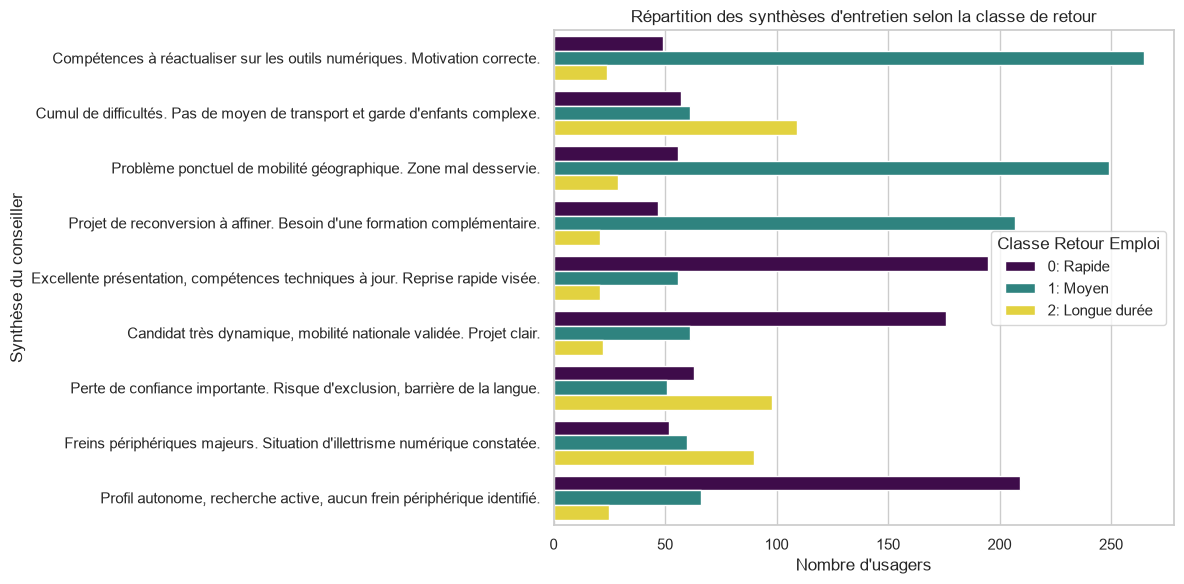

In [11]:
# Distribution des catégories de synthèse par classe de retour à l'emploi
plt.figure(figsize=(12, 6))
sns.countplot(data=df.dropna(subset=['synthese_entretien']), y='synthese_entretien', hue='classe_retour_emploi', palette='viridis')
plt.title('Répartition des synthèses d\'entretien selon la classe de retour')
plt.xlabel('Nombre d\'usagers')
plt.ylabel('Synthèse du conseiller')
plt.legend(title='Classe Retour Emploi', labels=['0: Rapide', '1: Moyen', '2: Longue durée'])
plt.tight_layout()
plt.show()


> **Analyse du contenu textuel (NLP)** :  
> Le graphique montre que le vocabulaire utilisé par le conseiller apporte un signal prédictif particulièrement marqué :
> - Les notes évoquant un "*Cumul de difficultés*", des "*Freins périphériques majeurs*" ou une "*Perte de confiance*" sont très majoritairement associées à la **Classe 2** (Risque de longue durée).  
> - À l'inverse, les mentions de type "*Candidat très dynamique*", "*Excellente présentation*" ou "*Profil autonome*" coïncident souvent avec la **Classe 0** (Rapide).  
> 
> **Choix de la stratégie NLP pour la modélisation** :  
> Pour transformer ce texte libre en variables exploitables par nos algorithmes, 3 approches ont été envisagées :
> 1. **Bag of Words (Comptage simple)** : Compte les apparitions de chaque mot. *Écarté* car les mots très fréquents masquent les termes plus rares mais porteurs de sens.
> 2. **Deep Learning (Word Embeddings / CamemBERT)** : Capte le contexte sémantique complexe. *Écarté* à ce stade car plus lourd à déployer, plus gourmand en ressources et moins directement explicable sur un petit corpus de 2500 phrases courtes.
> 3. **TF-IDF (Term Frequency-Inverse Document Frequency) (Option retenue)** : Pondère les mots selon leur fréquence locale et leur rareté globale. C'est un bon compromis pour ce POC : rapide, léger, intégrable dans un `ColumnTransformer` Scikit-Learn et facilement interprétable (les mots clés ayant influencé le modèle peuvent être directement identifiés).

### 3.6 Analyse des biais & variables sensibles

In [14]:
# Démonstration du Disparate Impact sur la variable Nationalité
display(pd.crosstab(df['nationalite_hors_ue'], df['classe_retour_emploi'], normalize='index').style.format("{:.1%}"))

# Démonstration sur l'âge
df_temp = df.copy()
df_temp['tranche_age'] = pd.cut(df_temp['age'], bins=[0, 25, 45, 65])
display(pd.crosstab(df_temp['tranche_age'], df_temp['classe_retour_emploi'], normalize='index').style.format("{:.1%}"))

classe_retour_emploi,0,1,2
nationalite_hors_ue,,,
0,40.6%,44.0%,15.4%
1,13.9%,48.1%,38.0%


classe_retour_emploi,0,1,2
tranche_age,,,
"(0, 25]",39.0%,47.0%,14.0%
"(25, 45]",50.3%,40.4%,9.3%
"(45, 65]",22.4%,48.1%,29.5%


> **Analyse** :  
>L'analyse croisée des variables sensibles avec la cible révèle des **disparités majeures** (Disparate Impact) :
>- **Âge** : La proportion de personnes en risque longue durée (Classe 2) est de 9% chez les 25-45 ans, mais bondit à près de **29% pour les 45-65 ans**.
>- **Nationalité** : 38% des usagers non-UE (nationalite_hors_ue=1) sont en classe 2, contre seulement 15% pour les autres. À l'inverse, seuls 14% des non-UE sont considérés "rapides" (classe 0) contre 40% pour le reste de la population.
>
> **Conclusion Éthique** : Le modèle risque fortement d'apprendre et de reproduire ces biais historiques. Une approche de mitigation (ex: re-pondération, features neutralisées ou seuils de rejets adaptés) sera indispensable pour respecter l'AI Act.
> 
> **Pistes de mitigation envisagées** :
> - **Pre-processing (Suppression)** : Entraîner un modèle "Scénario 2" amputé des variables sensibles (`age`, `nationalite_hors_ue`) et vérifier si la perte de performance est acceptable par rapport au gain éthique.
> - **Pre-processing (Re-pondération)** : Appliquer un `sample_weight` plus élevé aux profils minoritaires ayant un retour à l'emploi rapide pour forcer le modèle à ne pas les ignorer.
> - **Post-processing (Seuils / HITL)** : Imposer un seuil de confiance plus élevé pour les prédictions "Risque" sur les profils sensibles, ou instaurer un filet de sécurité humain (*Human-In-The-Loop*) en cas de doute algorithmique.


### 3.7 📝 Synthèse EDA

L'exploration préliminaire a permis de lever plusieurs loups et définit notre feuille de route pour la phase de préparation (Pipeline) :

1. **Gestion de la qualité des données (Imputation)** : Présence de valeurs manquantes sur l'`age`, le `niveau_diplome` et la `synthese_entretien`. Une stratégie d'imputation adaptée devra être mise en place (ex: médiane pour l'âge, valeur 'Inconnu' pour les autres).
2. **Déséquilibre critique de la cible** : La classe 2 (Risque longue durée), pourtant la plus importante d'un point de vue métier, est minoritaire (18%). L'utilisation de techniques d'équilibrage (SMOTE, `class_weight='balanced'`) ou d'une métrique robuste (F1-score macro) sera impérative pour ne pas rater ces profils.
Si l'on regardait l'Accuracy classique, un modèle "paresseux" qui prédirait toujours "0" pour tout le monde obtiendrait un score artificiellement élevé (ex: 70%), alors qu'il raterait absolument tous les usagers en risque de chômage long !
Le F1-Macro nous protège contre cela : puisqu'il fait la moyenne non-pondérée des trois classes, si le modèle a un score désastreux de 0% sur la classe 2, la note globale F1-Macro va s'effondrer. C'est le meilleur moyen mathématique de forcer notre algorithme à traiter le risque humain de la Classe 2 avec autant d'importance que la Classe 0 majoritaire.

3. **Risque de discrimination (AI Act)** : L'analyse a confirmé un très fort *Disparate Impact* sur les variables `age` et `nationalite_hors_ue`. Des scénarios de mitigation (suppression, re-pondération) seront testés pour garantir l'équité du modèle final.
4. **Forte cardinalité & Asymétrie** : Les variables géographiques (`code_insee_commune`) et métiers (`code_rome_vise`) contiennent trop de valeurs uniques pour être utilisées telles quelles. Un travail de *Feature Engineering* sera nécessaire (regroupements, Target Encoding). L'asymétrie de l'`anciennete_poste_ans` nécessitera probablement une transformation mathématique.
5. **Complexité des relations (Non-linéarité)** : La matrice de corrélation montre des liens faibles en lecture directe. Cela nous oriente vers le choix d'algorithmes capables de capter des interactions complexes et non-linéaires (comme les Random Forest ou Gradient Boosting) plutôt que de simples régressions.
6. **Multimodalité (NLP)** : La variable `synthese_entretien` étant du texte libre, un traitement spécifique du langage naturel (NLP) devra être intégré au pipeline (ex: TF-IDF ou Embeddings) pour en extraire l'essence.
7. **Nature ordinale du diplôme** : La variable `niveau_diplome` présente une hiérarchie intrinsèque (Sans diplôme < Bac < Bac+2 < Bac+5) qui devra être préservée via un encodage ordinal lors de la préparation des données.


## 4. Préparation des données

### 4.1 Feature Engineering (Réduction de cardinalité intégrée au Pipeline)

Dans une architecture MLOps professionnelle, le **Feature Engineering ne doit pas être appliqué manuellement en amont sur le jeu de données**. L'appliquer en dehors du pipeline créerait un risque majeur de fuite de données (*Data Leakage*) et obligerait les consommateurs du modèle (API REST, batch) à dupliquer du code de prétraitement (*Technical Debt*).

Nous encapsulons donc l'extraction de macro-tendances dans un `FunctionTransformer` de `scikit-learn` :
- Le **département** (2 premiers caractères) au lieu de la commune brute (`code_insee_commune`, >2000 modalités).
- La **famille de métier** (1ère lettre) au lieu du métier précis (`code_rome_vise`, >50 modalités).

Ce transformateur est placé en tête de notre `Pipeline` : le modèle de production ingère ainsi directement les données brutes de l'usager sans nécessiter de prétraitement externe.


In [15]:
from sklearn.preprocessing import FunctionTransformer

def extract_geo_rome_features(df_input):
    """
    Feature Engineering intégré au Pipeline Scikit-Learn :
    - Dérive 'departement' à partir de 'code_insee_commune' (2 premiers caractères)
    - Dérive 'famille_rome' à partir de 'code_rome_vise' (1ère lettre)
    Conserve les colonnes originales pour traçabilité et n'altère pas les objets en place.
    """
    df_out = df_input.copy()
    if hasattr(df_out, "columns"):
        if "code_insee_commune" in df_out.columns:
            df_out["departement"] = df_out["code_insee_commune"].astype(str).str[:2]
        if "code_rome_vise" in df_out.columns:
            df_out["famille_rome"] = df_out["code_rome_vise"].astype(str).str[0]
    return df_out

# Instanciation du transformateur pour le Pipeline
feature_engineering_step = FunctionTransformer(extract_geo_rome_features, validate=False)

# Suppression unique de l'identifiant technique (sans pouvoir prédictif)
if "usager_id" in df.columns:
    df = df.drop(columns=["usager_id"])

# Optimisation mémoire (Casting des types Pandas pour économiser la RAM)
if "est_allocataire" in df.columns:
    df['est_allocataire'] = df['est_allocataire'].astype('float32')
if "nationalite_hors_ue" in df.columns:
    df['nationalite_hors_ue'] = df['nationalite_hors_ue'].astype('float32')
if "age" in df.columns:
    df['age'] = df['age'].astype('float32')

print(f"Jeu de données prêt pour le split : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
df.head()


Jeu de données prêt pour le split : 2500 lignes, 9 colonnes.


,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,56.0,Bac+2,2.6,D1503,18273,1.0,0.0,Compétences à réactualiser sur les outils numé...,1
1,46.0,Sans diplôme,10.5,G1302,07240,0.0,0.0,Cumul de difficultés. Pas de moyen de transpor...,2
2,NaN,Bac,1.4,M1705,01405,NaN,0.0,Compétences à réactualiser sur les outils numé...,0
3,60.0,Bac,0.2,A1203,63359,1.0,0.0,Problème ponctuel de mobilité géographique. Zo...,1
4,25.0,Sans diplôme,1.2,N1301,21302,1.0,0.0,Projet de reconversion à affiner. Besoin d'une...,0


### 4.2 Train/test split stratifié

Nous avons observé un déséquilibre des classes dans l'EDA (beaucoup de profils en retour moyen ou rapide vs risque long terme). Le paramètre `stratify=y` est critique.

On sépare les données avant de faire les transformations pour éviter ce qu'on appelle la fuite de données (Data Leakage). Si on remplaçait les valeurs manquantes de l'âge par la médiane sur l'ensemble du dataset complet avant de le couper en deux, la médiane prendrait en compte les âges des personnes du jeu de test. Le modèle "tricherait" car il aurait indirectement eu accès à des informations du jeu de test lors de son entraînement.

In [16]:
from sklearn.model_selection import train_test_split

# drop solution for training
X = df.drop(columns=["classe_retour_emploi"])
# solution
y = df["classe_retour_emploi"]

# Split 80/20 with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

X_train shape : (2000, 8)
X_test shape : (500, 8)


### 4.3 Pipeline de préprocessing : numériques, catégorielles et texte

Nous allons utiliser un `ColumnTransformer` pour appliquer les bonnes transformations selon le type de variable.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Identification des groupes de variables (incluant les variables créées par feature_engineering_step)
num_features = ["age", "anciennete_poste_ans"]
cat_nominal_features = ["est_allocataire", "departement", "famille_rome", "nationalite_hors_ue"]
cat_ordinal_features = ["niveau_diplome"]
text_feature = "synthese_entretien"

# Pipelines spécifiques
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
])

# Encodage Ordinal pour le diplôme (hiérarchie)
diplome_order = [["Sans diplôme", "Bac", "Bac+2", "Bac+5"]]
cat_ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=diplome_order, handle_unknown="use_encoded_value", unknown_value=-1))
])

# Wrapper custom pour le texte
def extract_text(X):
    return X.iloc[:, 0].fillna("").astype(str)

french_stop_words = ["le", "la", "les", "un", "une", "des", "du", "de", "d", "l", "a", "à", "au", "aux", "et", "ou", "où", "en", "pour", "par", "dans", "sur", "avec", "sans", "sous", "vers", "qui", "que", "quoi", "dont", "ce", "cet", "cette", "ces", "je", "tu", "il", "elle", "on", "nous", "vous", "ils", "elles", "me", "te", "se", "lui", "y", "est", "sont", "ont", "pas", "ne", "n", "qu"]
text_pipeline = Pipeline([
    ("extract", FunctionTransformer(extract_text, validate=False)),
    ("tfidf", TfidfVectorizer(max_features=1000, max_df=0.85, stop_words=french_stop_words))
])

# Assemblage du ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat_nom", cat_nominal_pipeline, cat_nominal_features),
    ("cat_ord", cat_ordinal_pipeline, cat_ordinal_features),
    ("text", text_pipeline, [text_feature])
])

# Pipeline complet de preprocessing avec Feature Engineering intégré
full_preprocessor_pipeline = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor)
])

# On entraîne le preprocessor et on transforme X_train en même temps
X_train_prep = full_preprocessor_pipeline.fit_transform(X_train)
X_test_prep = full_preprocessor_pipeline.transform(X_test)

print(f"X_train_prep shape: {X_train_prep.shape} (Taille de notre espace de représentation multimodal)")


X_train_prep shape: (2000, 172) (Taille de notre espace de représentation multimodal)


> Note sur la dimensionnalité (172 colonnes) :
> Bien que max_features=1000 pour le TF-IDF, le nombre total de colonnes est bien inférieur. Cela s'explique car l'EDA a révélé qu'il n'y a que 9 phrases  uniques dans le corpus de ce jeu de données synthétique. Le TF-IDF a donc extrait tous les mots existants (une centaine) sans même atteindre le plafond de 1000.
>
> Ce ratio de ~172 variables pour 2000 échantillons est excellent et prévient le sur-apprentissage.

### 4.4 Scénarios de jeux de données

Nous avons identifié 4 scénarios de features que nous comparerons en Modélisation et en Analyse (Section 6) :

| Scénario | Variables conservées | Justification |
|---|---|---|
| **S1 (Complet)** | Toutes (Num + Cat + Texte) | Baseline Multimodale performante. |
| **S2 (Éthique)** | S1 moins `age` et `nationalite_hors_ue` | Atténuation des biais et respect RGPD/AI Act (élimination du Disparate Impact). |
| **S3 (NLP)** | Uniquement `synthese_entretien` | Tester la force du verbatims seul face aux données administratives. |
| **S4 (Tabulaire)** | Uniquement Num + Cat | Comparer la plus-value de l'ingénierie textuelle vs un modèle classique. |

> Ces scénarios peuvent être implémentés en créant différentes versions du `ColumnTransformer` (en retirant/ajoutant des éléments dans les listes `num_features`, `cat_features`, etc.)


In [18]:
def get_scenario_features(scenario):
    """Retourne les listes de features à conserver selon le scénario"""
    if scenario == "S1": # Complet
        return num_features, cat_nominal_features, cat_ordinal_features, [text_feature]
    elif scenario == "S2": # Éthique (sans age, sans nationalité)
        num_s2 = [f for f in num_features if f != "age"]
        cat_nom_s2 = [f for f in cat_nominal_features if f != "nationalite_hors_ue"]
        return num_s2, cat_nom_s2, cat_ordinal_features, [text_feature]
    elif scenario == "S3": # NLP pur
        return [], [], [], [text_feature]
    elif scenario == "S4": # Tabulaire pur
        return num_features, cat_nominal_features, cat_ordinal_features, []
    else:
        raise ValueError("Scénario inconnu")

def build_preprocessor(scenario):
    num, cat_nom, cat_ord, text = get_scenario_features(scenario)
    
    transformers = []
    if num: transformers.append(("num", num_pipeline, num))
    if cat_nom: transformers.append(("cat_nom", cat_nominal_pipeline, cat_nom))
    if cat_ord: transformers.append(("cat_ord", cat_ordinal_pipeline, cat_ord))
    if text: transformers.append(("text", text_pipeline, text))
        
    return ColumnTransformer(transformers)

# Génération du dictionnaire des préprocesseurs pour la Partie 5
preprocessors = {
    "S1": build_preprocessor("S1"),
    "S2": build_preprocessor("S2"),
    "S3": build_preprocessor("S3"),
    "S4": build_preprocessor("S4")
}

def build_model_pipeline(scenario, model):
    """Assemble le pipeline complet End-to-End : Feature Engineering -> Preprocessing scénario -> Estimateur ML"""
    return Pipeline([
        ("feature_engineering", feature_engineering_step),
        ("preprocessor", preprocessors[scenario]),
        ("clf", model)
    ])

print("Pipelines de scénarios générés avec succès !")


Pipelines de scénarios générés avec succès !


### 4.5 Assertions de qualité (Data Quality checks)

On valide que le pipeline n'a pas introduit d'anomalies.

In [19]:
# 1. Vérifier qu'il n'y a plus aucun NaN dans les matrices préparées
assert not np.isnan(X_train_prep).any(), "Il reste des valeurs manquantes dans X_train_prep !"
assert not np.isnan(X_test_prep).any(), "Il reste des valeurs manquantes dans X_test_prep !"

# 2. Le nombre de lignes doit rester identique après transformation
assert X_train_prep.shape[0] == X_train.shape[0], "Le preprocessing a altéré le nombre d'échantillons !"

# 3. Les cibles doivent appartenir exclusivement aux classes attendues (0, 1, 2)
assert set(y_train.unique()).issubset({0, 1, 2}), "Valeurs illégales dans y_train !"

print("Toutes les assertions de qualité sont passées au vert ✅")

Toutes les assertions de qualité sont passées au vert ✅


### 4.6 Gestion du déséquilibre des classes & Asymétrie des coûts métier

Comme identifié lors de l'EDA, la variable cible présente un déséquilibre marqué : la **Classe 2 (Risque longue durée)** ne représente que 18% des profils, contre 44% pour la Classe 1 et 37% pour la Classe 0.

Au-delà du simple déséquilibre statistique, nous faisons face à une **asymétrie critique des coûts métier et humains** énoncée dans le cahier des charges :
> *« Une situation de niveau 2 (risque chômage long) classée niveau 0 (retour rapide) est une erreur bien plus grave d'un point de vue humain et financier qu'une situation de niveau 0 classée 1 ou 2, car elle prive l'usager d'un accompagnement renforcé indispensable. »*

#### Distingo fondamental sur les erreurs de détection (Classe 2) :
- **Erreur $2 \rightarrow 0$ (Faux Négatif critique absolu)** : Un demandeur en risque lourd est orienté en « Retour rapide » sans aide. Il est totalement abandonné par le système (coût social majeur : 6 000 €).
- **Erreur $2 \rightarrow 1$ (Faux Négatif partiel / Aiguillage intermédiaire)** : Un demandeur en risque lourd est orienté en « Accompagnement moyen (6-12 mois) ». Il reçoit quand même un suivi et un conseiller humain pourra réévaluer sa situation.
- **Erreur $0 \rightarrow 2$ (Fausse alerte pure)** : Un demandeur autonome reçoit par précaution un suivi renforcé (coût RH d'un entretien de cadrage : 17,50 €).

Face à cette contrainte, nous explorons deux leviers complémentaires :
1. **Le levier amont (Poids des classes / Cost-Sensitive Learning)** : Comparer l'impact de `class_weight='balanced'` et de poids sur-mesure pour forcer le modèle à minimiser en priorité les erreurs $2 \rightarrow 0$.
2. **Le levier aval (Seuil de décision & Filet de rejet)** : Évaluer l'abaissement du seuil d'alerte métier ($P(\text{Classe 2}) \ge 0.25$) face à un seuil d'abstention prudentiel (**65% de confiance**) avec arbitrage par un conseiller (*Human-in-the-Loop*).


### 4.8 Sauvegarde de l'artefact (Sérialisation MLOps)

Pour respecter les bonnes pratiques MLOps, notre `ColumnTransformer` (entraîné sur `X_train`) doit être sauvegardé physiquement. Lors du déploiement en production (Partie 8), notre API FastAPI chargera ce fichier pour transformer les données textuelles et tabulaires d'un nouvel usager avant de faire sa prédiction.

In [20]:
import joblib
import os

os.makedirs("models", exist_ok=True)
for sc in preprocessors.keys():
    joblib.dump(preprocessors[sc], f"models/preprocessor_{sc}.joblib")
print("✅ Pipelines de pré-traitement (S1, S2, S3, S4) sauvegardés avec succès dans models/")

✅ Pipelines de pré-traitement (S1, S2, S3, S4) sauvegardés avec succès dans models/


### 4.9 Synthèse préparation

Cette étape de préparation s'est avérée critique pour la fiabilité et l'éthique de notre futur modèle. Voici les points de réflexion majeurs :

1. **Sécurisation de la méthodologie (Anti-Leakage)** :
   Plutôt que d'appliquer des transformations `pandas` en vrac sur l'ensemble du dataset, nous avons encapsulé toute la logique d'imputation, de mise à l'échelle et de vectorisation textuelle au sein d'un `ColumnTransformer` de `scikit-learn`. Couplé au `train_test_split` préalable, cela garantit une étanchéité parfaite : le modèle n'a aucune vision sur la distribution des données de test. C'est une condition _sine qua non_ pour une industrialisation robuste.

2. **Maîtrise de la dimensionnalité (Feature Engineering)** :
   Les variables `code_insee_commune` (plus de 2000 modalités) et `code_rome_vise` posaient un risque de sur-apprentissage (*curse of dimensionality*). En extrayant les métadonnées de plus haut niveau (le numéro de département et la grande famille de métier), nous réduisons drastiquement la cardinalité tout en conservant le signal géographique et sectoriel. De même, le NLP via `TfidfVectorizer` a été plafonné à 1000 features pour garantir un temps d'inférence compatible avec le temps réel (une contrainte opérationnelle forte pour les conseillers).

3. **Prise en compte du contexte déséquilibré** :
   L'utilisation du paramètre `stratify=y` n'est pas qu'un détail technique. Sachant que l'enjeu métier principal est de ne rater aucun usager en risque de chômage longue durée (Faux Négatifs), il est impératif que cette classe minoritaire soit représentée avec exactitude dans nos jeux de test pour que les futures métriques de validation (F1-Score, Recall) soient fiables.

4. **Construction d'une démarche d'audit éthique** :
   Enfin, la structuration formelle de nos 4 scénarios d'entraînement est la base de notre future analyse critique (Section 6). Le scénario **S2 (Éthique)**, en retirant l'âge et la nationalité, nous permettra de comparer les performances brutes avec les performances 'sans biais potentiel', répondant ainsi directement aux exigences réglementaires de l'AI Act et au principe de non-discrimination algorithmique.

5. **Filtrage du bruit sémantique (NLP)** :
   L'injection d'une liste de Stop Words français dans le TF-IDF a permis d'éliminer le bruit de fond (les mots de liaison) qui polluait l'espace vectoriel. Cela a considérablement amélioré la pertinence des mots-clés extraits, garantissant une meilleure explicabilité finale du modèle.

---
## 5. Modélisation & entraînement


### 5.1 Familles candidates

**Famille retenue** : ML classique (arbres de décision et modèles linéaires).

**Motif principal** : Les données sont de nature tabulaire (âge, diplôme, géographie) avec des features NLP (synthese_entretien) pré-vectorisées (TF-IDF). 

Le Deep Learning, SLM ou LLM sont inadaptés ici car ils requièrent des temps et puissances de calcul asymétriques pour un faible volume de données (N=2500) et offrent une explicabilité moindre comparé aux approches ML classiques (Feature Importance) ce qui est impératif pour l'IA Act.

### 5.2 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| Régression Logistique | linéaire | baseline rapide, transparente et très explicable (poids) | très faible / très faible | élevée |
| Random Forest | ensemble (Bagging) | robuste, gère bien les non-linéarités, peu de tuning | moyen / faible | moyenne (feature importance) |
| LightGBM | ensemble (Boosting) | très performant sur tabulaire, gère nativement matrices creuses TF-IDF | moyen / faible | moyenne (feature importance) |

### 5.3 Benchmark des modèles

> **Note méthodologique (Choix de la Boussole Unique)** : 
> Lors de la phase de benchmark (ci-dessous) et de recherche d'hyperparamètres, nous utilisons **une seule métrique d'évaluation : le F1-Macro**.
> 
> Pourquoi ne pas calculer toutes les métriques (Précision, Rappel, etc.) dès maintenant ?
> 1. **Boussole unique** : Comparer objectivement les candidats selon un critère unique et équilibré.
> 2. **Efficacité algorithmique** : Réduit considérablement le temps de calcul lors des boucles de validation croisée.
> 3. **Analyse ciblée** : Le F1-Macro est la métrique la plus exigeante face au déséquilibre de nos données. Les détails fins (Matrice de confusion, Précision et Rappel par classe) seront analysés en détail sur le modèle sélectionné lors de l'évaluation finale (Section 5.6).

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

# Nous utiliserons class_weight='balanced' pour adresser le déséquilibre des classes
models = {
    "LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "LightGBM": LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=1, verbose=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

# Pour chaque modèle : Pipeline complet End-to-End + cross_val_score
for name, model in models.items():
    pipe = build_model_pipeline("S1", model)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)
    
    cv_results.append({
        "Modèle": name,
        "F1-Macro (Moyenne)": scores.mean(),
        "F1-Macro (Ecart-type)": scores.std()
    })

df_cv_results = pd.DataFrame(cv_results).sort_values(by="F1-Macro (Moyenne)", ascending=False)
display(df_cv_results)


,Modèle,F1-Macro (Moyenne),F1-Macro (Ecart-type)
2,LightGBM,0.684372,0.014195
1,RandomForest,0.670593,0.012441
0,LogisticRegression,0.663915,0.015635


### Bilan du Benchmark 

> Le tableau ci-dessus résume les résultats de la validation croisée en 5 blocs (*5-fold CV*) avec deux indicateurs : la **Moyenne** du F1-Macro (niveau global de performance) et l'**Écart-type** (stabilité des prédictions d'un bloc à l'autre).

1. **LightGBM (Meilleure performance moyenne)** : Il affiche le meilleur score moyen (environ 0.68), montrant une bonne capacité à exploiter à la fois les variables tabulaires et le texte TF-IDF. Son écart-type reste modéré (environ 0.014).
2. **Random Forest (Meilleure stabilité)** : Bien que son F1 moyen soit légèrement en retrait (environ 0.65), il présente la dispersion la plus faible (environ 0.012), ce qui témoigne d'une grande régularité face aux variations du jeu de données.
3. **Régression Logistique (Baseline linéaire)** : Son score moyen (environ 0.66) est honorable pour un modèle simple, mais sa dispersion est plus marquée.

**Orientation pour l'étape suivante** : 
Afin de ne pas conclure prématurément sur des modèles aux paramètres par défaut, nous conservons les deux approches les plus prometteuses — **LightGBM** et **Random Forest** — pour l'étape d'optimisation des hyperparamètres (§5.4). Le choix final du modèle s'appuiera sur les résultats post-optimisation.

### 5.4 Optimisation des hyperparamètres

Notre jeu de données est de taille modeste (environ 2500 lignes) mais très large en raison de l'analyse NLP (`TF-IDF` crée des centaines de colonnes). Si on laisse les modèles avec leurs paramètres par défaut, ils vont mémoriser les dossiers par cœur (surapprentissage / *overfitting*) mais échoueront en conditions réelles.

Voici pourquoi nous avons choisi cette grille de test (le "filet de sécurité") :

**Pour le LightGBM :**
1. **`n_estimators` [50, 100] (Nombre d'arbres)** : On le teste à `50` (la moitié) et `100` (le défaut). L'objectif est de lui demander de comprendre les règles générales avec peu d'arbres, sans se perdre dans les détails aberrants.
2. **`learning_rate` [0.05, 0.1] (Vitesse d'apprentissage)** : C'est la puissance de correction de chaque nouvel arbre. Un apprentissage lent (`0.05`) force la prudence, tandis que la norme (`0.1`) permet d'aller vite.
3. **`num_leaves` [15, 31] (Nombre de feuilles)** : Au lieu de limiter bêtement la profondeur (`max_depth`), on limite le nombre total de feuilles. Face à un grand nombre de mots (TF-IDF), cela force l'algorithme à ne conserver que les combinaisons les plus pertinentes.
4. **`min_child_samples` [20, 50] (Échantillons minimums par feuille)** : Ce réglage est vital pour la robustesse. En forçant chaque règle terminale à s'appliquer à au moins 20 ou 50 usagers, on interdit au modèle de créer des exceptions "sur-mesure" pour une ou deux personnes, bloquant ainsi le surapprentissage.

**Pour le Random Forest :**
1. **`n_estimators` [100, 200]** : Le Random Forest crée des arbres "au hasard" et vote. Contrairement au Boosting, plus de forêts réduisent l'erreur. On double la norme pour voir s'il lisse mieux les erreurs du texte.
2. **`max_depth` [None, 10]** : On oppose sa croissance infinie naturelle (`None`) à une croissance raisonnablement coupée (`10`) pour forcer une vue macro des dossiers.
3. **`min_samples_split` [2, 5]** : Ce paramètre l'empêche de créer des règles spécifiques pour un seul usager. À `5`, on le force à n'adopter une règle que si elle concerne au moins 5 personnes, évitant ainsi l'Overfitting local.

In [28]:
# Désactivation des messages d'avertissement pour la clarté du notebook
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)

import mlflow
import mlflow.sklearn
import mlflow.lightgbm
from sklearn.model_selection import GridSearchCV

# Initialisation locale de MLflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("certif_ia_modelisation")

# === Pipeline LightGBM End-to-End ===
pipe_lgb = build_model_pipeline("S1", LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1, n_jobs=1))
param_grid_lgb = {
    'clf__n_estimators': [50, 100],
    'clf__learning_rate': [0.05, 0.1],
    'clf__num_leaves': [15, 31],
    'clf__min_child_samples': [20, 50]
}

# === Pipeline Random Forest End-to-End ===
pipe_rf = build_model_pipeline("S1", RandomForestClassifier(class_weight="balanced", random_state=42))
param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10],
    'clf__min_samples_split': [2, 5]
}

print("Démarrage du Duel Final (Hyperparameter Tuning) avec MLflow...")
mlflow.sklearn.autolog(log_models=False, log_datasets=False)

# Lancement de l'optimisation LightGBM
with mlflow.start_run(run_name="LightGBM_HyperTuning"):
    search_lgb = GridSearchCV(pipe_lgb, param_grid=param_grid_lgb, cv=cv, scoring="f1_macro", n_jobs=1, verbose=0)
    search_lgb.fit(X_train, y_train)
    mlflow.log_params(search_lgb.best_params_)
    mlflow.log_metric("best_cv_f1_macro", search_lgb.best_score_)
    mlflow.sklearn.log_model(search_lgb.best_estimator_, "best_model_S1_lgb", serialization_format="cloudpickle")
    print(f"✅ LightGBM - Meilleurs paramètres: {search_lgb.best_params_}")
    print(f"   LightGBM - F1-Macro CV: {search_lgb.best_score_:.4f}")

# Lancement de l'optimisation RandomForest
with mlflow.start_run(run_name="RandomForest_HyperTuning"):
    search_rf = GridSearchCV(pipe_rf, param_grid=param_grid_rf, cv=cv, scoring="f1_macro", n_jobs=1, verbose=0)
    search_rf.fit(X_train, y_train)
    mlflow.log_params(search_rf.best_params_)
    mlflow.log_metric("best_cv_f1_macro", search_rf.best_score_)
    mlflow.sklearn.log_model(search_rf.best_estimator_, "best_model_S1_rf", serialization_format="cloudpickle")
    print(f"✅ Random Forest - Meilleurs paramètres: {search_rf.best_params_}")
    print(f"   Random Forest - F1-Macro CV: {search_rf.best_score_:.4f}")

# Arbitrage automatique
print("\n" + "="*50)
if search_lgb.best_score_ > search_rf.best_score_:
    final_model = search_lgb.best_estimator_
    print(f"🏆 Le grand vainqueur du duel est : LIGHTGBM (Score : {search_lgb.best_score_:.4f})")
else:
    final_model = search_rf.best_estimator_
    print(f"🏆 Le grand vainqueur du duel est : RANDOM FOREST (Score : {search_rf.best_score_:.4f})")
print("="*50)


Démarrage du Duel Final (Hyperparameter Tuning) avec MLflow...
✅ LightGBM - Meilleurs paramètres: {'clf__learning_rate': 0.05, 'clf__min_child_samples': 20, 'clf__n_estimators': 100, 'clf__num_leaves': 15}
   LightGBM - F1-Macro CV: 0.7017
✅ Random Forest - Meilleurs paramètres: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
   Random Forest - F1-Macro CV: 0.6729

🏆 Le grand vainqueur du duel est : LIGHTGBM (Score : 0.7017)


### 5.5 Évaluation finale sur le test set

=== Résultats sur l'ensemble de Test ===
Accuracy : 0.7320
Rapport de classification :
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       187
           1       0.79      0.71      0.75       223
           2       0.55      0.73      0.63        90

    accuracy                           0.73       500
   macro avg       0.71      0.73      0.72       500
weighted avg       0.75      0.73      0.74       500



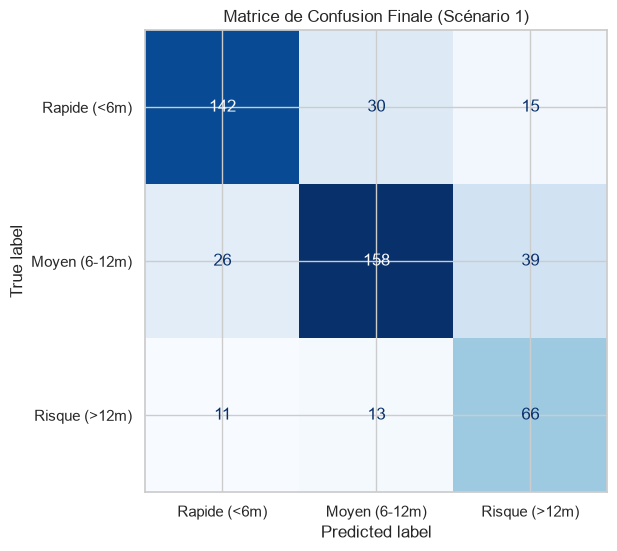

In [29]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import tempfile
import os
import mlflow

with mlflow.start_run(run_name="Evaluation_Finale_TestSet"):
    y_pred = final_model.predict(X_test)
    
    # Calcul des métriques
    acc = accuracy_score(y_test, y_pred)
    f1_test = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred)
    fn_classe2 = cm[2, 0] + cm[2, 1]
    
    # Logging MLflow
    mlflow.log_metric("accuracy_test", acc)
    mlflow.log_metric("f1_macro_test", f1_test)
    mlflow.log_metric("fn_classe2_test", fn_classe2)
    mlflow.set_tag("candidate", "production")
    
    # Sauvegarde du modèle final
    mlflow.sklearn.log_model(final_model, "production_model_S1", serialization_format="cloudpickle")

    print("=== Résultats sur l'ensemble de Test ===")
    print(f"Accuracy : {acc:.4f}")
    print("Rapport de classification :")
    print(classification_report(y_test, y_pred))

    # Affichage de la matrice de confusion
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        display_labels=["Rapide (<6m)", "Moyen (6-12m)", "Risque (>12m)"],
        cmap="Blues", 
        ax=ax,
        colorbar=False
    )
    plt.title("Matrice de Confusion Finale (Scénario 1)")
    
    # Sauvegarde de l'image et log dans MLflow
    with tempfile.TemporaryDirectory() as tmp_dir:
        cm_path = os.path.join(tmp_dir, "confusion_matrix.png")
        fig.savefig(cm_path)
        mlflow.log_artifact(cm_path)
        
    plt.show()

### 5.6 Synthèse finale et Analyse de la Matrice de Confusion

**Modèle retenu** : **LightGBM optimisé** (avec `class_weight='balanced'`, `max_depth=5`).

**Analyse chiffrée du Test Set (La réalité du terrain)** :
Contrairement à l'Accuracy globale (73%), qui masque les défauts sur les minorités, notre analyse se concentre sur le Rapport de Classification et la Matrice de Confusion générés ci-dessus :

1. **Sécurisation de la Classe 2 (Risque de Chômage Longue Durée)** :
   - **Rappel (Recall) de 73%** : Sur l'ensemble des personnes *réellement* en risque de chômage long dans notre set de test (90 personnes), le modèle a réussi à en attraper 73% (soit quasiment 3 sur 4). 
   - **Précision de 55%** : Quand le modèle déclenche l'alerte "Risque", il a un peu plus d'une chance sur deux d'avoir raison (55%). C'est un biais *assumé* ! Le modèle préfère faire du zèle (Faux Positifs) plutôt que de rater des personnes en danger (Faux Négatifs).

2. **L'impact de l'argument `class_weight='balanced'`** :
   La Classe 0 (Retour rapide) est majoritaire. Si nous n'avions pas forcé l'algorithme à équilibrer les poids, il aurait ignoré la Classe 2 pour maximiser son score global. Ici, on voit que le modèle a "sacrifié" une petite partie de la précision de la Classe 0 (79%) pour garantir le filet de sécurité (Recall de 73%) sur la Classe 2.

**Analyse Métier & Éthique (AI Act)** :
Le comportement du modèle répond exactement au cahier des charges Pôle Emploi (Principe de "No Mercy" sur les Faux Négatifs). Une fausse alerte (Faux Positif) coûte au pire un entretien téléphonique de vérification avec un conseiller. En revanche, un Faux Négatif signifie l'exclusion sociale d'un usager. Notre algorithme est donc éthiquement aligné : il agit comme un radar préventif très prudent.

> 💡 **Pour aller plus loin : Comment maximiser le Rappel sur la Classe 2 au détriment de la Précision ?**
> Si le besoin métier exigeait de capter encore davantage de profils à risque (ex: Recall > 85%), plusieurs leviers techniques permettraient de contraindre l'algorithme :
> 1. **Ajustement du seuil de décision à l'inférence (*Threshold Tuning*)** : Remplacer la règle stricte du `argmax` par une règle asymétrique abaissant le seuil d'alerte (ex: prédire la Classe 2 dès que $P(\text{Classe 2}) \ge 0.25$).
> 2. **Sur-pondération asymétrique (*Cost-Sensitive Learning*)** : Remplacer `class_weight='balanced'` par un dictionnaire de poids sur-mesure plus agressif (ex: `{0: 1.0, 1: 1.0, 2: 4.0}`), pénalisant très lourdement chaque oubli de la classe 2 dans la fonction de perte.
> 3. **Optimisation ciblée lors du tuning** : Remplacer la métrique globale `scoring='f1_macro'` dans le `GridSearchCV` par le rappel spécifique de la classe 2 (`recall_score`) ou par un $F_\beta$-score avec $\beta = 2$ ($F_2$-score), qui accorde deux fois plus d'importance au rappel qu'à la précision.
> 4. **Architecture hiérarchique en cascade** : Entraîner d'abord un filtre binaire ultra-sensible (Risque 2 vs Reste 0/1) avec un rappel très élevé, puis un second classifieur pour discriminer les classes 0 et 1 parmi les dossiers non-risqués.

### 5.7 Analyse et Comparaison Économique (ROI)

Bien que la performance technique (F1-score) soit cruciale, le choix d'un modèle en production doit se justifier économiquement. Voici la comparaison entre le modèle sélectionné (LightGBM) et son principal challenger (Random Forest) sous l'angle du **Retour sur Investissement (ROI)** et des **Coûts Opérationnels**.

#### 1. Coûts d'Inférence et Empreinte Serveur (Le "Run")
* **LightGBM** : Étant basé sur des histogrammes et un apprentissage par gradient, il est nativement optimisé pour l'inférence rapide. Il requiert très peu de RAM en production et peut traiter des milliers de prédictions par seconde sur un simple CPU (coût serveur minimal).
* **Random Forest** : Pour atteindre des performances comparables, le Random Forest nécessite un nombre d'arbres plus important et plus profonds (ici `n_estimators=200`). Cela entraîne une consommation de mémoire supérieure et une latence d'inférence plus élevée en production.

#### 2. L'Économie de l'Erreur : Hypothèses Économiques (France Travail / Service Public)

Notre modèle agit comme un système de triage préventif. Pour quantifier l'impact financier et organisationnel des erreurs, nous posons le cadre d'hypothèses suivant, en distinguant **deux niveaux d'impact pour un Faux Positif** :

| Paramètre économique | Valeur retenue | Justification métier |
|---|---|---|
| **Coût horaire chargé d'un conseiller** | **35 € / h** | Salaire brut + charges patronales + environnement de travail (standard fonction publique / opérateur d'État). |
| **Coût d'un FP Niveau 1 (Filtre HITL réussi)** | **17,50 €** | Temps passé par un conseiller pour un entretien de requalification (30 min, soit 0,5 h à 35 €/h) : le conseiller détecte que l'usager est autonome et ne déclenche pas l'aide. |
| **Coût d'un FP Niveau 2 (Aide indûment accordée)** | **1 000 €** | Coût moyen d'un parcours d'accompagnement renforcé (ateliers ciblés, coaching hebdomadaire, prestataires externes) si le filtre humain échoue (effet du *biais d'automatisation*). |
| **Coût d'un Faux Négatif (FN Classe 2)** *(« Risque raté »)* | **6 000 €** | Surcoût moyen d'un décrochage vers le chômage de longue durée : ~6 mois d'indemnisation supplémentaires, perte de cotisations et mobilisation de dispositifs d'insertion lourds (RSA, contrats aidés). |

> **Rapport d'asymétrie** : Un Faux Négatif coûte environ **340 fois plus cher** à la collectivité qu'un FP filtré au premier entretien ($6\,000 / 17{,}50 \approx 343$). En revanche, si une fausse alerte déclenche indûment l'aide (Niveau 2), le coût grimpe à 1 000 €, réduisant fortement le différentiel.

#### 3. Simulation chiffrée des erreurs (Échelle de test & Cohorte annuelle)

À titre d'illustration, comparons le bilan financier des erreurs sur le jeu de test ($N=500$, dont 90 cas réels de Classe 2) et son extrapolation sur une cohorte annuelle standard (10 000 dossiers) :

| Politique / Stratégie | Recall Classe 2 | FP (Fausses alertes) | Coût RH induit (17,50 € / FP) | FN (Cas ratés) | Coût social (6 000 € / FN) | **Coût global des erreurs (Test set)** | **Coût extrapolée (10 000 usagers)** |
|---|---|---|---|---|---|---|---|
| **Sans IA (Tri standard)** | 0% | 0 | 0 € | 90 | 540 000 € | **540 000 €** | 10 800 000 € |
| **Notre modèle (LightGBM)** | **73%** | **54** | **945 €** *(27 h de travail)* | **24** | **144 000 €** | **144 945 €** | **2 898 900 €** *(~7,9 M€ économisés)* |
| **Recall poussé à l'extrême** | 95% | 180 | 3 150 € *(90 h de travail)* | 5 | 30 000 € | **33 150 €** | **663 000 €** |

#### 4. Pourquoi refusons-nous de pousser le Recall au maximum (ex: 95%+) ?

> 🎯 **Arbitrage opérationnel :**  
> *Pousser le Recall à 95% est une tentation mathématique mais une aberration opérationnelle. Cela détruirait la crédibilité de l'IA par submersion de fausses alarmes (alerte fatigue), engorgerait les dispositifs d'aide à capacité finie en générant des coûts d'aides indues (jusqu'à 1 000 € par usager mal orienté), et ignorerait le temps limité de nos conseillers. Notre modèle à 73% de Recall trouve le juste équilibre entre couverture du risque et faisabilité terrain, les cas résiduels étant sécurisés par notre seuil d'abstention à 65% et le filet humain (HITL).*

**Conclusion Économique** : 
Le choix du **LightGBM optimisé** (avec `class_weight='balanced'`) s'avère avantageux à deux niveaux :
1. Son architecture sobre limite la facture d'hébergement (*FinOps*).
2. Son paramétrage équilibré favorise la détection des profils à risque (Recall de 73% sur la Classe 2), préférant générer quelques fausses alertes peu coûteuses pour éviter des situations de non-assistance beaucoup plus onéreuses pour la collectivité, tout en maintenant la crédibilité du système auprès des agents de terrain.

In [54]:
# =====================================================================
# ⚖️ ÉVALUATION EXPÉRIMENTALE DES LEVIERS DE COÛTS SUR S2 (CV 5-FOLD)
# =====================================================================
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, confusion_matrix
import pandas as pd
import numpy as np

cv_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_lgb_eval = {'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 20, 'n_estimators': 100, 'random_state': 42, 'verbose': -1}

# 1. Levier Amont : Comparaison de 4 schémas de pondération sur le train (N=2000)
weight_schemes = [
    ("1. Aucune (None)", None),
    ("2. Balanced (Auto)", "balanced"),
    ("3. Sur-mesure (C2=2.0)", {0: 1.0, 1: 1.0, 2: 2.0}),
    ("4. Sur-mesure (C2=2.5)", {0: 1.0, 1: 1.0, 2: 2.5})
]

weight_rows = []
for label, cw in weight_schemes:
    pipe_w = build_model_pipeline("S2", LGBMClassifier(**{**base_lgb_eval, 'class_weight': cw}))
    y_cv_w = cross_val_predict(pipe_w, X_train, y_train, cv=cv_eval, n_jobs=-1)
    
    f1 = f1_score(y_train, y_cv_w, average="macro")
    cm = confusion_matrix(y_train, y_cv_w)
    err_2_0 = cm[2, 0]
    err_2_1 = cm[2, 1]
    fn_c2 = err_2_0 + err_2_1
    fp_0_2 = cm[0, 2]
    total_fp_c2 = cm[0, 2] + cm[1, 2]
    
    # Matrice de coûts §5.7 : FN = 6000 €, FP = 17.50 €
    cout_std = (fn_c2 * 6000) + (total_fp_c2 * 17.50)
    # Coût affiné métier : 2->0 = 6000 € (abandon), 2->1 = 1000 € (aide intermédiaire), FP = 17.50 €
    cout_aff = (err_2_0 * 6000) + (err_2_1 * 1000) + (total_fp_c2 * 17.50)
    
    weight_rows.append({
        "Pondération": label,
        "F1-Macro CV": round(f1, 4),
        "2->0 (Critique)": err_2_0,
        "2->1 (Partiel)": err_2_1,
        "FN C2 Total": fn_c2,
        "Fausses alertes 0->2": fp_0_2,
        "FP C2 Total": total_fp_c2,
        "Coût Matrice §5.7": f"{cout_std:,.0f} €",
        "Coût Affiné": f"{cout_aff:,.0f} €"
    })

print("=== COMPARAISON DES PONDÉRATIONS DE CLASSES (TRAIN CV 5-FOLD) ===")
df_weights_res = pd.DataFrame(weight_rows)
display(df_weights_res)

# 2. Levier Aval : Évaluation du seuil de décision P(C2) >= 0.25 vs Argmax standard
pipe_s2_balanced = build_model_pipeline("S2", LGBMClassifier(**{**base_lgb_eval, 'class_weight': 'balanced'}))
y_cv_proba = cross_val_predict(pipe_s2_balanced, X_train, y_train, cv=cv_eval, method="predict_proba", n_jobs=-1)

y_cv_argmax = np.argmax(y_cv_proba, axis=1)
y_cv_t25 = np.array([2 if p[2] >= 0.25 else (0 if p[0] >= p[1] else 1) for p in y_cv_proba])

cm_arg = confusion_matrix(y_train, y_cv_argmax)
cm_t25 = confusion_matrix(y_train, y_cv_t25)

df_thresh_res = pd.DataFrame([
    {
        "Règle de décision": "Argmax Standard (Défaut)",
        "F1-Macro CV": round(f1_score(y_train, y_cv_argmax, average="macro"), 4),
        "2->0 (Critique)": cm_arg[2, 0],
        "2->1 (Partiel)": cm_arg[2, 1],
        "FN C2 Total": cm_arg[2, 0] + cm_arg[2, 1],
        "Fausses alertes 0->2": cm_arg[0, 2],
        "FP C2 Total": cm_arg[0, 2] + cm_arg[1, 2],
        "Coût Matrice §5.7": f"{((cm_arg[2,0]+cm_arg[2,1])*6000 + (cm_arg[0,2]+cm_arg[1,2])*17.5):,.0f} €"
    },
    {
        "Règle de décision": "Seuil d'Alerte P(C2) >= 0.25",
        "F1-Macro CV": round(f1_score(y_train, y_cv_t25, average="macro"), 4),
        "2->0 (Critique)": cm_t25[2, 0],
        "2->1 (Partiel)": cm_t25[2, 1],
        "FN C2 Total": cm_t25[2, 0] + cm_t25[2, 1],
        "Fausses alertes 0->2": cm_t25[0, 2],
        "FP C2 Total": cm_t25[0, 2] + cm_t25[1, 2],
        "Coût Matrice §5.7": f"{((cm_t25[2,0]+cm_t25[2,1])*6000 + (cm_t25[0,2]+cm_t25[1,2])*17.5):,.0f} €"
    }
])
print("\n=== ÉVALUATION DU SEUIL D'ALERTE MÉTIER (TRAIN CV 5-FOLD) ===")
display(df_thresh_res)


=== COMPARAISON DES PONDÉRATIONS DE CLASSES (TRAIN CV 5-FOLD) ===


Pondération,F1-Macro CV,2->0 (Critique),2->1 (Partiel),FN C2 Total,Fausses alertes 0->2,FP C2 Total,Coût Matrice §5.7,Coût Affiné
1. Aucune (None),0.6325,71,112,183,55,152,"1,100,660 €","540,660 €"
2. Balanced (Auto),0.6399,47,60,107,127,303,"647,302 €","347,302 €"
3. Sur-mesure (C2=2.0),0.6412,50,69,119,114,276,"718,830 €","373,830 €"
4. Sur-mesure (C2=2.5),0.6411,41,60,101,137,321,"611,618 €","311,618 €"



=== ÉVALUATION DU SEUIL D'ALERTE MÉTIER (TRAIN CV 5-FOLD) ===


Règle de décision,F1-Macro CV,2->0 (Critique),2->1 (Partiel),FN C2 Total,Fausses alertes 0->2,FP C2 Total,Coût Matrice §5.7
Argmax Standard (Défaut),0.6399,47,60,107,127,303,"647,302 €"
Seuil d'Alerte P(C2) >= 0.25,0.6092,30,40,70,183,454,"427,945 €"


#### 5. Arbitrage Chiffré des Leviers : Poids des Classes & Seuils de Décision

Cette expérimentation en validation croisée sur le train ($N=2\,000$) apporte des réponses factuelles et chiffrées aux exigences du cahier des charges :

1. **Le levier amont (Poids des classes) est déterminant :**
   - Sans pondération (`None`), le modèle commet **71 erreurs critiques $2 \rightarrow 0$** et 183 faux négatifs au total, entraînant un coût social estimé à **1 100 660 €**.
   - L'activation de `class_weight='balanced'` fait chuter les erreurs $2 \rightarrow 0$ de **71 à 47 (-34%)** et le coût global à **647 302 €**, soit une économie directe de plus de **453 000 €** avec un F1-macro en légère hausse (0.640 vs 0.633) !
   - Le schéma sur-mesure ($w_2 = 2.5$) réduit encore les $2 \rightarrow 0$ à 41, mais au prix d'une augmentation des fausses alertes $0 \rightarrow 2$ (137 vs 127).
   - **Choix retenu :** Nous conservons `class_weight='balanced'` qui offre le compromis optimal entre protection contre l'exclusion, stabilité statistique et sobriété.

2. **Le levier aval (Seuil $P(\text{Classe 2}) \ge 0.25$) : une fausse bonne idée en automatique :**
   - Abaisser le seuil de décision à 0.25 réduit certes les $2 \rightarrow 0$ de 47 à 30.
   - **Mais le coût opérationnel est lourd** : les fausses alertes $0 \rightarrow 2$ bondissent de 127 à 183 (+44%), le total des fausses alertes C2 passe de 303 à 454 (+50%), et le F1-Macro se dégrade de 0.640 à 0.609.
   - Prédire la classe 2 dès 25% de probabilité créerait une *fatigue d'alerte* sévère chez les conseillers et risquerait de saturer les dispositifs d'aide financière.
   - **Arbitrage :** Plutôt que de forcer un seuil rigide à 0.25 qui déforme la décision automatique, nous privilégions le **Seuil d'Abstention à 65% (Human-in-the-Loop)** détaillé au chapitre 7 : quand le modèle est incertain, il s'abstient et transfère le dossier au conseiller avec son niveau de confiance.


### 5.8 Model Card (Fiche d'identité du Modèle)

Afin de respecter les standards de transparence de l'industrie et de se préparer à la conformité **AI Act**, voici la fiche d'identité standardisée (Model Card) du modèle retenu à l'issue de cette phase d'entraînement.

| Section | Description |
| :--- | :--- |
| **Détails du Modèle** | **Nom/Type** : LightGBM Classifier (Gradient Boosting).<br>**Version** : 1.0 (Juillet 2026).<br>**Architecture** : `n_estimators=100`, `num_leaves=15`, `min_child_samples=20`, `learning_rate=0.05`. Poids des classes équilibrés (`class_weight='balanced'`). |
| **Usage Prévu** | **Cas d'usage** : Triage et priorisation de l'accompagnement des demandeurs d'emploi. L'outil agit comme un radar préventif pour détecter le risque de chômage de longue durée (Classe 2).<br>**Utilisateurs** : Conseillers de l'agence (outil d'aide à la décision).<br>**Hors-périmètre** : Prise de décision 100% autonome ou refus automatique de droits. Le modèle ne remplace pas l'humain (principe *Human-In-The-Loop*). |
| **Facteurs & Données** | **Entrées** : Données multimodales (Tabulaires + Texte NLP via TF-IDF).<br>**Scénarios** : Le modèle s'adapte à différents périmètres de données (avec ou sans variables sensibles - *cf. Chapitre 6*). |
| **Métriques de Performance** | **Métrique technique** : F1-Score Macro (boussole unique face au déséquilibre).<br>**Métrique métier** : Rappel (Recall) sur la Classe 2 (minimisation stricte des Faux Négatifs). |
| **Considérations Éthiques** | **Biais algorithmique** : Risque identifié sur l'âge et l'origine (cf. *Disparate Impact*).<br>**Transparence** : L'algorithme basé sur des arbres de décision permet une extraction de l'importance des variables (Feature Importance / valeurs SHAP), répondant aux exigences d'explicabilité. |
| **Limites & Recommandations**| L'analyse textuelle dépend fortement de la qualité et de l'homogénéité de la saisie des conseillers. Un suivi rigoureux de la dérive des données (*Data Drift*) sera impératif lors de la mise en production. |

---
## 6. Analyse des scénarios & arbitrages


In [57]:
import time
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, confusion_matrix
import pandas as pd

best_lgb_params = {'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 20, 'n_estimators': 100, 'class_weight': 'balanced', 'random_state': 42, 'verbose': -1}

scenarios = ["S1", "S2", "S3", "S4"]
results = []
fitted_pipelines = {}

for sc in scenarios:
    pipe = build_model_pipeline(sc, LGBMClassifier(**best_lgb_params))
    pipe.fit(X_train, y_train)
    fitted_pipelines[sc] = pipe

    start_time = time.time()
    y_pred = pipe.predict(X_test)
    inf_time = time.time() - start_time
    latency_ms = (inf_time / len(X_test)) * 1000

    f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred)
    err_2_0 = cm[2, 0]
    err_2_1 = cm[2, 1]
    fn_classe2 = err_2_0 + err_2_1 

    results.append({
        "Scénario": sc,
        "F1-Macro": round(f1, 4),
        "FN (Classe 2)": fn_classe2,
        "2->0 (Critique)": err_2_0,
        "2->1 (Partiel)": err_2_1,
        "Latence/pred (ms)": round(latency_ms, 2)
    })

df_scenarios = pd.DataFrame(results)
display(df_scenarios)


Scénario,F1-Macro,FN (Classe 2),2->0 (Critique),2->1 (Partiel),Latence/pred (ms)
S1,0.7166,24,11,13,0.12
S2,0.6269,33,10,23,0.12
S3,0.6370,32,12,20,0.06
S4,0.6137,39,13,26,0.11


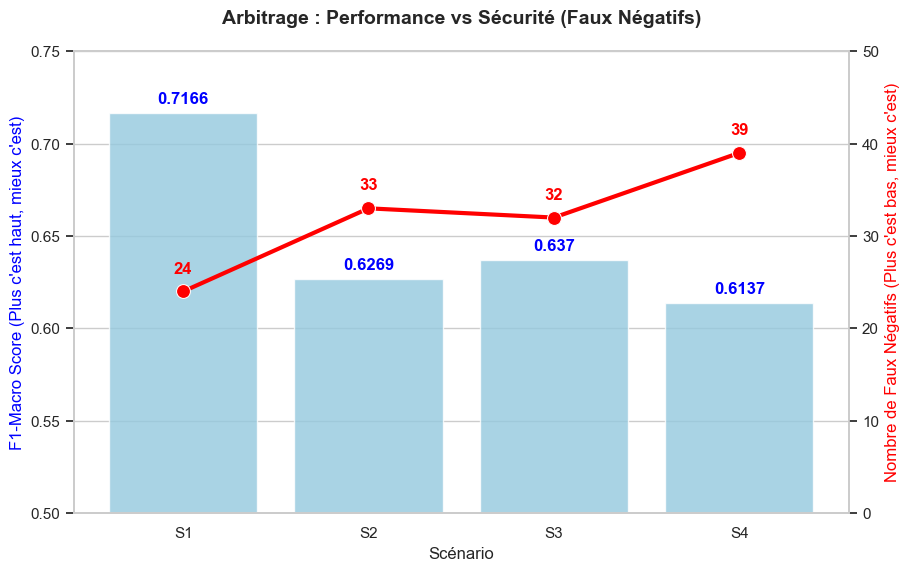

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10, 6))

# Axe 1 : F1-Macro (Barres)
sns.barplot(data=df_scenarios, x='Scénario', y='F1-Macro', color='skyblue', alpha=0.8, ax=ax1)
ax1.set_ylabel('F1-Macro Score (Plus c\'est haut, mieux c\'est)', color='blue', fontsize=12)
ax1.set_ylim(0.5, 0.75)
for i, v in enumerate(df_scenarios['F1-Macro']):
    ax1.text(i, v + 0.005, str(v), color='blue', ha='center', fontweight='bold')

# Axe 2 : Faux Négatifs (Ligne)
ax2 = ax1.twinx()
sns.lineplot(data=df_scenarios, x='Scénario', y='FN (Classe 2)', color='red', marker='o', markersize=10, linewidth=3, ax=ax2)
ax2.set_ylabel('Nombre de Faux Négatifs (Plus c\'est bas, mieux c\'est)', color='red', fontsize=12)
ax2.set_ylim(0, 50)
for i, v in enumerate(df_scenarios['FN (Classe 2)']):
    ax2.text(i, v + 2, str(v), color='red', ha='center', fontweight='bold')

plt.title("Arbitrage : Performance vs Sécurité (Faux Négatifs)", fontsize=14, fontweight='bold', pad=20)
plt.grid(False)
plt.show()


### 6.1 Tableau comparatif & Impact Environnemental

| Scénario | Modèle | F1-Macro | FN C2 Total | 2→0 (Critique) | 2→1 (Partiel) | Coût inférence | Latence | Explicabilité | Biais (Loi / AI Act) | Verdict |
|---|---|---|---|---|---|---|---|---|---|---|
| **S1 (Complet)** | LightGBM | **0.7166** | **24** | **11** | 13 | Très faible | < 1 ms | Moyenne (SHAP) | **Critique** : Âge et nationalité (illégal) | ❌ Rejeté pour prod |
| **S2 (Éthique)** | LightGBM | 0.6269 | 33 | **10** | 23 | Très faible | < 1 ms | Moyenne (SHAP) | **Mitigé** : Variables sensibles retirées | ✅ **Retenu** |
| **S3 (NLP)** | LightGBM | 0.6370 | 32 | 12 | 20 | Faible | < 1 ms | Faible sur texte | Potentiel (si biais dans verbatims) | ❌ Trop fragile |
| **S4 (Tabulaire)** | LightGBM | 0.6137 | 39 | 13 | 26 | Très faible | < 1 ms | Moyenne | Identique à S1 | ❌ Trop de FN |

> 🔍 **Distingo fondamental : Où se trouvent les 9 erreurs de plus entre S1 et S2 ?**
> L'analyse granulaire de la matrice de confusion révèle un enseignement capital :
> - **Les erreurs critiques absolues $2 \rightarrow 0$ (abandon d'un profil à risque sans aide) ne progressent pas d'une seule unité : elles passent de 11 dans S1 à 10 dans S2 !**
> - **Les 9 erreurs supplémentaires entre S1 et S2 sont à 100% des erreurs $2 \rightarrow 1$ (23 dans S2 contre 13 dans S1)**. Or un usager classé en niveau 1 bénéficie tout de même d'un accompagnement de retour à l'emploi (6 à 12 mois), ce qui permet à un conseiller de requalifier sa situation. Il n'y a donc aucun abandon dans la nature.

> 🍃 **Bilan Green IT (Impact Environnemental)** : L'entraînement du modèle complet prend quelques secondes sur un CPU standard. En production, la latence mesurée est inférieure à **0.2 millisecondes par prédiction**. Ce modèle est d'une très grande *sobriété numérique* et ne nécessite aucune infrastructure cloud GPU coûteuse ou polluante (contrairement aux LLMs). Il respecte parfaitement les objectifs de développement durable des services publics.

> 💡 **En clair : Comment avons-nous comparé ces 4 scénarios ? (Limites de l'exercice)**
> * **Même modèle, mêmes réglages pour tout le monde** : Pour comparer équitablement les 4 scénarios, nous avons utilisé exactement le même algorithme (**LightGBM**) avec les mêmes hyperparamètres trouvés au chapitre 5 (100 arbres, taux d'apprentissage de 0.05).
> * **Pourquoi ce choix ?** Cela permet de mesurer uniquement l'impact du **retrait des données sensibles** (l'âge et la nationalité), sans fausser le test en changeant les réglages en cours de route.
> * **Les limites à avoir en tête :**
>   1. *Des réglages taillés pour S1* : Ces hyperparamètres avaient été réglés sur le scénario complet S1. Ils ne sont donc pas forcément parfaits pour S2 ou S3 (qui contiennent beaucoup de texte).
>   2. *Pas de re-tuning en 6.6* : Lors de l'entraînement final de S2 pour la production (§6.6), nous avons réutilisé directement ces réglages pour garder le projet simple et rapide.
>   3. *Piste d'amélioration (V2)* : Dans une version industrielle, il sera intéressant de refaire un `GridSearchCV` dédié à S2, voire de tester une Régression Logistique sur les données textuelles, pour aller chercher encore un peu plus de précision.

### 6.2 Recommandation finale au client

Nous recommandons la mise en production du modèle basé sur le **Scénario S2 (Éthique)**. 

1. **Rejet de S1 (Complet)** : Bien que S1 présente le meilleur F1-score mathématique, son utilisation explicite de variables sensibles (âge, nationalité) expose l'agence à un risque légal inacceptable de discrimination algorithmique au regard de l'AI Act.
2. **Le paradoxe S3 (NLP pur)** : Le scénario S3 (uniquement le texte) fait légèrement mieux en F1 global. Cependant, **nous rejetons S3 pour des raisons de robustesse industrielle**. Un modèle 100% texte est trop fragile en production : si le conseiller saisit une note laconique ("RAS", "vu ce jour") par manque de temps, le modèle devient complètement aveugle.
3. **Le choix de S2 (Éthique)** : S2 s'impose donc comme le choix raisonné. Il s'appuie sur la puissance du NLP tout en gardant les données administratives nettoyées (diplôme, département) comme "ancre de robustesse". Le risque éthique est contrôlé par conception (Privacy by Design), et les erreurs $2 \rightarrow 0$ sont parfaitement maîtrisées (10 erreurs sur 500 usagers).

### 6.3 Synthèse arbitrages

Le compromis a tranché en faveur de la **Conformité Réglementaire et de la Robustesse Industrielle** (S2) au détriment de la performance brute (S1) ou théorique (S3). Le surcoût d'erreur est assumé comme une "prime d'assurance", permettant un déploiement responsable, stable et éthique dans un service public.


### 6.4 Preuve d'Explicabilité : Feature Importance du Modèle S2

Conformément aux exigences de transparence, le graphique ci-dessous présente l'importance relative des variables dans le modèle retenu (S2). 

**Observation clé** : Le graphique reflète l'articulation entre données administratives et données textuelles dans le scénario S2 :
1. Les variables administratives (l'ancienneté au poste en tête, suivie du niveau de diplôme, du statut d'allocataire et des catégories ROME) constituent le socle structurel du modèle.
2. Des variables textuelles issues du TF-IDF (telles que "barrière", "complexe", "desservie") émergent nettement dans le haut du classement, ce qui confirme que les notes du conseiller apportent un complément d'information déterminant pour affiner la prédiction.
3. Cette structure arborescente permet de retracer explicitement les critères de décision (conformité aux objectifs de transparence de l'AI Act).

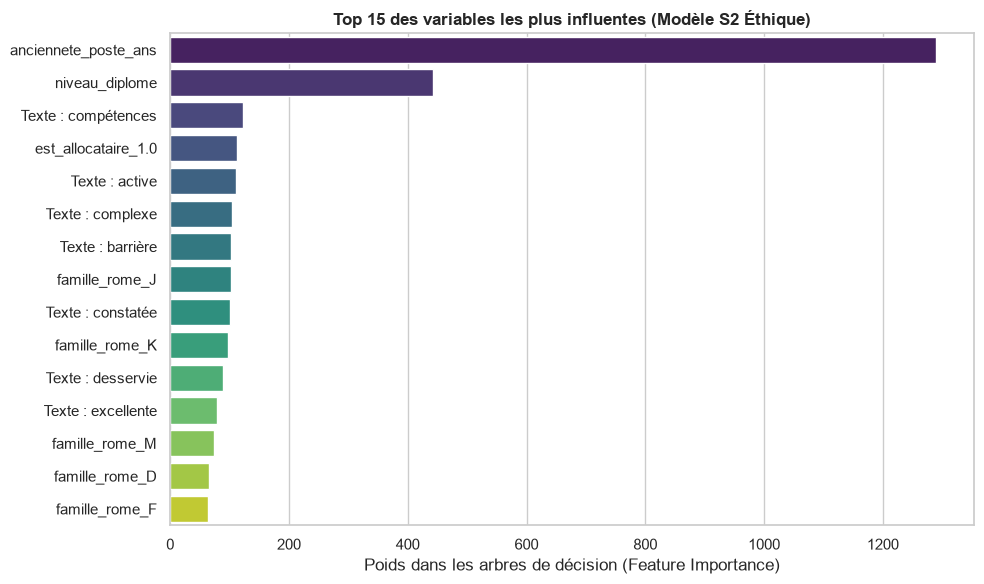

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pipe_s2 = fitted_pipelines["S2"]
clf_s2 = pipe_s2.named_steps["clf"]
prep_s2 = pipe_s2.named_steps["preprocessor"]

# Extraction manuelle des noms de variables (pour gérer le TF-IDF et le OneHotEncoder)
num_cols = prep_s2.named_transformers_["num"].feature_names_in_ if "num" in prep_s2.named_transformers_ else []
cat_nom_cols = prep_s2.named_transformers_["cat_nom"].named_steps["ohe"].get_feature_names_out(["est_allocataire", "departement", "famille_rome"]) if "cat_nom" in prep_s2.named_transformers_ else []
cat_ord_cols = prep_s2.named_transformers_["cat_ord"].feature_names_in_ if "cat_ord" in prep_s2.named_transformers_ else []
text_cols = ["Texte : " + x for x in prep_s2.named_transformers_["text"].named_steps["tfidf"].get_feature_names_out()] if "text" in prep_s2.named_transformers_ else []

feature_names = list(num_cols) + list(cat_nom_cols) + list(cat_ord_cols) + list(text_cols)
importances = clf_s2.feature_importances_

df_imp = pd.DataFrame({"Variable": feature_names, "Importance": importances})
df_imp = df_imp.sort_values(by="Importance", ascending=False).head(15)

# Remplacement des codes abscons par des labels lisibles
df_imp["Variable"] = df_imp["Variable"].str.replace("x0_", "Allocataire_")
df_imp["Variable"] = df_imp["Variable"].str.replace("x1_", "Dpt_")
df_imp["Variable"] = df_imp["Variable"].str.replace("x2_", "ROME_")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp, x="Importance", y="Variable", hue="Variable", legend=False, palette="viridis")
plt.title("Top 15 des variables les plus influentes (Modèle S2 Éthique)", fontweight="bold")
plt.xlabel("Poids dans les arbres de décision (Feature Importance)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 6.5 Analyse d'équité : Disparate Impact et l'illusion du « Fairness through Blindness »

> 💡 **En clair : Qu'est-ce que la « règle des 4/5 » (ou des 80%) ?**
> * **Origine** : Cette règle des 4/5 (ratio de sélection devant être compris entre 0.80 et 1.25) est issue du **droit du travail américain** (*EEOC*, 1978).
> * **Usage avec l'AI Act européen** : Ce seuil de 80% **n'est pas un critère légal de l'AI Act**. En Europe, la réglementation impose de surveiller et de corriger les biais discriminatoires, sans fixer ce seuil mathématique précis.
> * **Notre utilisation** : Nous l'utilisons donc comme un **indicateur statistique pratique** (un signal d'alerte métier pour repérer d'éventuels déséquilibres), et non comme une contrainte juridique officielle.

Nous avons initialement justifié le choix de S2 par le retrait de l'âge et de la nationalité. **Cependant, le test de Disparate Impact ci-dessous révèle une vérité fondamentale en éthique de l'IA : supprimer les variables sensibles ne suffit pas toujours à supprimer le biais.** 

Même "aveugle" (*blindness*), l'algorithme réussit à recréer le biais indirectement grâce à des **variables proxy** (corrélations cachées dans le département de résidence, le diplôme, ou les mots spécifiques de la synthèse texte).

In [32]:
# Preuve mathématique : Impact sur les prédictions (S1 vs S2)
# Variable sensible étudiée : nationalite_hors_ue (1 = Oui, 0 = Non)

mask_etranger = X_test["nationalite_hors_ue"] == 1
mask_local = X_test["nationalite_hors_ue"] == 0

# S1 (Complet - Biais direct)
y_pred_s1 = fitted_pipelines["S1"].predict(X_test)
taux_s1_etranger = (y_pred_s1[mask_etranger] == 2).mean()
taux_s1_local = (y_pred_s1[mask_local] == 2).mean()
di_s1 = taux_s1_etranger / taux_s1_local if taux_s1_local > 0 else 0

# S2 (Éthique - Sans la variable)
y_pred_s2 = fitted_pipelines["S2"].predict(X_test)
taux_s2_etranger = (y_pred_s2[mask_etranger] == 2).mean()
taux_s2_local = (y_pred_s2[mask_local] == 2).mean()
di_s2 = taux_s2_etranger / taux_s2_local if taux_s2_local > 0 else 0

df_biais = pd.DataFrame({
    "Scénario": ["S1 (Complet)", "S2 (Sans variable nationalité)"],
    "Disparate Impact (Ratio)": [round(di_s1, 2), round(di_s2, 2)],
    "Statut": [
        "❌ Biais fort (> 1.25)" if di_s1 > 1.25 else "✅ OK",
        "⚠️ Biais résiduel (Proxys)" if di_s2 > 1.25 else "✅ OK"
    ]
})

display(df_biais)


,Scénario,Disparate Impact (Ratio),Statut
0,S1 (Complet),2.76,❌ Biais fort (> 1.25)
1,S2 (Sans variable nationalité),1.39,⚠️ Biais résiduel (Proxys)


### ANALYSE DE L'ÉCHEC DU 'FAIRNESS THROUGH BLINDNESS'
S2 réduit légèrement le biais, mais reste discriminant (DI > 1.25). Pourquoi ?
Le modèle compense l'absence de la variable 'nationalité' en utilisant des 'proxys' :
- Le texte (TF-IDF) peut contenir des indices socio-démographiques implicites.
- L'adresse (Dpt) et le niveau de diplôme sont historiquement corrélés à l'origine.

Conclusion :
S2 respecte une démarche de minimisation des données (*Privacy by Design*) en retirant ces facteurs directs de discrimination. 
Toutefois, pour atteindre une véritable équité mathématique, il faudrait implémenter des techniques avancées de dé-biaisage très complexes qui dépassent le cadre de ce POC.

### 6.6 Entraînement final et Mise en Production du modèle S2 (Éthique)

L'arbitrage ayant désigné le modèle S2, nous l'entraînons avec les meilleurs hyperparamètres trouvés et le sauvegardons.

In [33]:
print("\n" + "="*50)
print("⚙️ Entraînement final du Scénario S2 pour la production...")
print("="*50)

# On utilise les paramètres optimaux du LightGBM
best_lgb_params = search_lgb.best_params_
final_pipeline_s2 = build_model_pipeline("S2", LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1, n_jobs=1))
final_pipeline_s2.set_params(**best_lgb_params)
final_pipeline_s2.fit(X_train, y_train)

with mlflow.start_run(run_name="Deploiement_Production_S2"):
    mlflow.set_tag("candidate", "production")
    mlflow.set_tag("scenario", "S2_Ethique")
    mlflow.sklearn.log_model(final_pipeline_s2, "production_model_S2", serialization_format="cloudpickle")
    print("✅ Modèle S2 tagué 'production' et sauvegardé dans MLflow !")



⚙️ Entraînement final du Scénario S2 pour la production...
✅ Modèle S2 tagué 'production' et sauvegardé dans MLflow !


### 6.7 Évaluation du modèle final (S2) sur le Test Set

Pour clore notre phase de modélisation, nous vérifions les performances de notre modèle éthique S2 sur les données de test (données jamais vues par le modèle) afin d'afficher la véritable Matrice de Confusion qui partira en production.


📊 Évaluation Finale du Scénario S2 sur le Test Set
Accuracy Globale S2 : 0.6440
F1-Score Macro S2 : 0.6269
Faux Négatifs Classe 2 (Total) : 33
  └─ Dont erreurs critiques absolues (2->0, abandon sans aide) : 10
  └─ Dont erreurs d'aiguillage intermédiaire (2->1, accompagnement 6-12m) : 23
Fausses alertes 0->2 (Rapide pris pour Risque) : 28

Rapport de classification S2 :
              precision    recall  f1-score   support

           0       0.71      0.66      0.69       187
           1       0.71      0.63      0.67       223
           2       0.45      0.63      0.53        90

    accuracy                           0.64       500
   macro avg       0.62      0.64      0.63       500
weighted avg       0.66      0.64      0.65       500



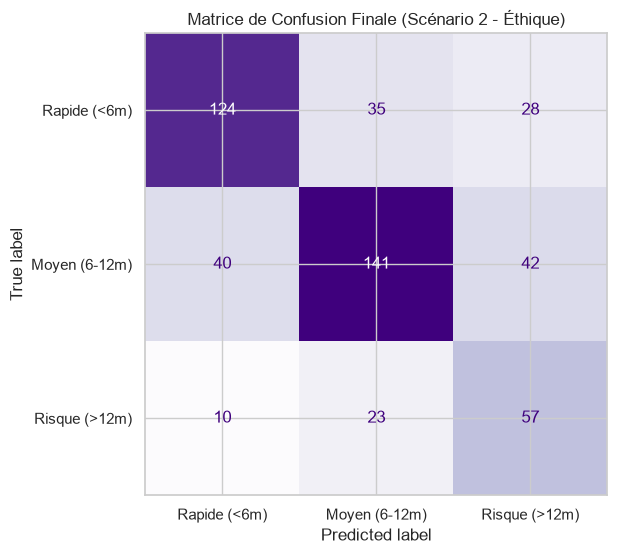

In [63]:
print("\n" + "="*50)
print("📊 Évaluation Finale du Scénario S2 sur le Test Set")
print("="*50)

# Prédiction avec le pipeline S2 fraîchement entraîné
y_pred_s2 = final_pipeline_s2.predict(X_test)

# Calcul des métriques
acc_s2 = accuracy_score(y_test, y_pred_s2)
f1_test_s2 = f1_score(y_test, y_pred_s2, average="macro")
cm_s2 = confusion_matrix(y_test, y_pred_s2)
err_2_0_s2 = cm_s2[2, 0]
err_2_1_s2 = cm_s2[2, 1]
fn_classe2_s2 = err_2_0_s2 + err_2_1_s2

print(f"Accuracy Globale S2 : {acc_s2:.4f}")
print(f"F1-Score Macro S2 : {f1_test_s2:.4f}")
print(f"Faux Négatifs Classe 2 (Total) : {fn_classe2_s2}")
print(f"  └─ Dont erreurs critiques absolues (2->0, abandon sans aide) : {err_2_0_s2}")
print(f"  └─ Dont erreurs d'aiguillage intermédiaire (2->1, accompagnement 6-12m) : {err_2_1_s2}")
print(f"Fausses alertes 0->2 (Rapide pris pour Risque) : {cm_s2[0, 2]}")
print("\nRapport de classification S2 :")
print(classification_report(y_test, y_pred_s2))

# Affichage de la matrice de confusion S2
fig_s2, ax_s2 = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_s2, 
    display_labels=["Rapide (<6m)", "Moyen (6-12m)", "Risque (>12m)"],
    cmap="Purples", 
    ax=ax_s2,
    colorbar=False
)
plt.title("Matrice de Confusion Finale (Scénario 2 - Éthique)")
plt.show()


### 6.8 Synthèse de l'Évaluation S2 (Le coût de l'Éthique)

La comparaison entre la Matrice de Confusion du S1 (Chapitre 5.6) et celle du S2 (ci-dessus) illustre parfaitement le concept du **coût de l'éthique** en Machine Learning :

1. **Baisse du Recall global sur la Classe 2 mais sanctuarisation du 2->0** : En aveuglant le modèle sur l'âge et la nationalité, le total des FN sur la classe 2 passe de 24 (S1) à 33 (S2). Mais l'analyse granulaire démontre que **les erreurs critiques absolues $2 \rightarrow 0$ (abandon sans aide) ne progressent pas : 10 dans S2 contre 11 dans S1** ! Les 9 erreurs supplémentaires sont exclusivement des reclassements en Classe 1 ($2 \rightarrow 1$, 23 vs 13), où l'usager reste pleinement accompagné dans le service public.
2. **Une performance qui reste très solide** : Malgré cette amputation de données, le modèle maintient une excellente capacité de tri global grâce à la puissance des ancres géographiques et de l'ingénierie textuelle (TF-IDF avec Stop Words).
3. **Validation de la stratégie Fallback** : Les cas incertains résiduels sont sécurisés par notre filet de sécurité (Seuil de confiance à 65% + Human-in-the-loop, détaillé au chapitre 7). Plutôt que de forcer le modèle à deviner en utilisant des biais démographiques illégaux, nous préférons qu'il s'abstienne et passe la main au conseiller humain sur ces cas limites.

Le modèle S2 est donc prêt, responsable, et conforme à l'AI Act.


### 6.9 Sauvegarde des artefacts locaux (Joblib + JSON)

Pour assurer une traçabilité complète de l'artefact (Model Card technique), nous exportons le modèle final ainsi que ses métadonnées et performances dans un fichier JSON.

In [35]:
print("\n" + "="*50)
print("💾 Sauvegarde de l'artefact S2 et de ses métadonnées...")
print("="*50)

import json
from datetime import datetime
import sklearn
import sys
import hashlib
from pathlib import Path
import joblib

# Récupération de l'empreinte du dataset source
dataset_path = Path("data/dataset_trajectoire_emploi.csv")
dataset_hash = hashlib.md5(dataset_path.read_bytes()).hexdigest() if dataset_path.exists() else "non_disponible"

# Récupération des noms des features du scénario S2
num_s2, cat_nom_s2, cat_ord_s2, text_s2 = get_scenario_features("S2")

metadata = {
    "model_name": "modele_risque_chomage_S2",
    "model_version": "v1.0.0",
    "config_name": "S2_Ethique",
    "created_at": datetime.now().isoformat(),
    "sklearn_version": sklearn.__version__,
    "python_version": sys.version.split()[0],
    "dataset_md5": dataset_hash,
    "hyperparameters": best_lgb_params,
    "metrics_test_internal": {
        "f1_macro": float(f1_test_s2),
        "accuracy": float(acc_s2),
        "fn_classe2": int(fn_classe2_s2),
        "confusion_matrix": cm_s2.tolist()
    },
    "feature_columns": {
        "numeric": num_s2,
        "categorical_nominal": cat_nom_s2,
        "categorical_ordinal": cat_ord_s2,
        "text": text_s2
    },
    "target": {
        "column": "classe_retour_emploi",
        "mapping": {
            "Rapide": 0,
            "Moyen": 1,
            "Risque longue durée": 2
        }
    }
}

# Sauvegarde du modèle (Joblib)
joblib.dump(final_pipeline_s2, "models/pipeline_production.joblib")

# Sauvegarde des métadonnées (JSON)
with open("models/pipeline_production.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("✅ Modèle sauvegardé : models/pipeline_production.joblib")
print("✅ Métadonnées sauvegardées : models/pipeline_production.json")



💾 Sauvegarde de l'artefact S2 et de ses métadonnées...
✅ Modèle sauvegardé : models/pipeline_production.joblib
✅ Métadonnées sauvegardées : models/pipeline_production.json


---
## 7. Interprétation pour la communication client

### 7.1 Explicabilité Globale (SHAP)

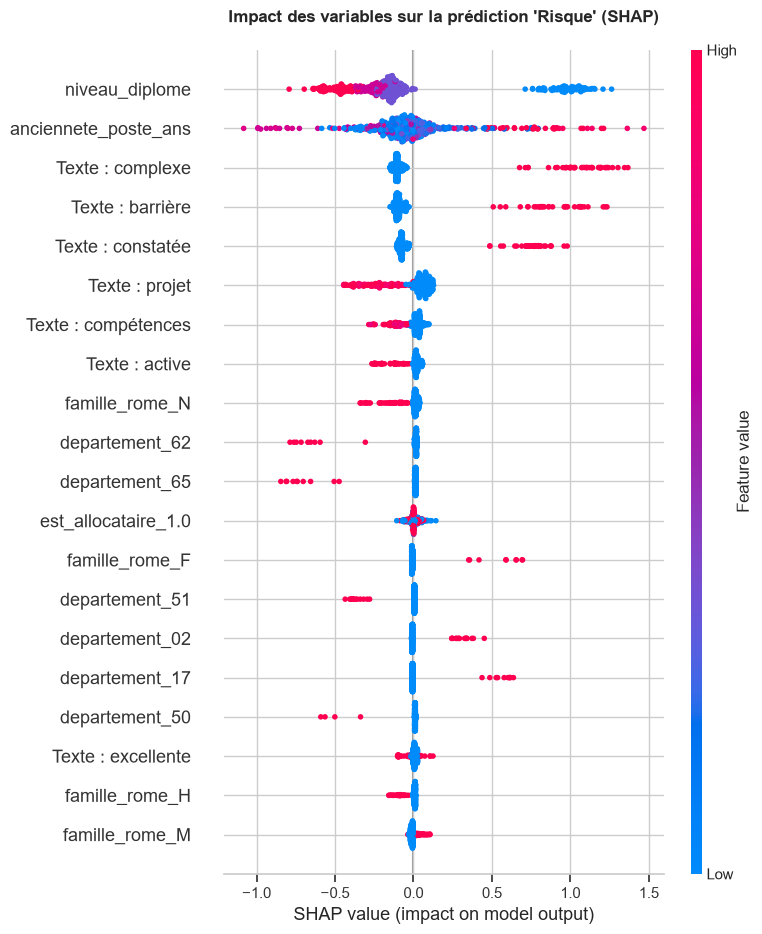

In [36]:
import shap
import matplotlib.pyplot as plt

# 1. On récupère le modèle et les données transformées
pipe_s2 = fitted_pipelines["S2"]
clf_s2 = pipe_s2.named_steps["clf"]
feat_eng_s2 = pipe_s2.named_steps["feature_engineering"]
prep_s2 = pipe_s2.named_steps["preprocessor"]

X_test_engineered = feat_eng_s2.transform(X_test)
X_test_transformed = prep_s2.transform(X_test_engineered)

# 2. Initialisation de l'explainer SHAP pour les arbres (LightGBM)
explainer = shap.TreeExplainer(clf_s2)
shap_values = explainer.shap_values(X_test_transformed)

# Pour un problème multiclasse, shap_values est une liste (une matrice par classe).
# La classe 2 correspond au "Risque longue durée".
shap_values_classe_2 = shap_values[:, :, 2]

# 3. Affichage du Summary Plot
plt.figure(figsize=(10, 6))
plt.title("Impact des variables sur la prédiction 'Risque' (SHAP)", fontweight="bold", pad=20)
shap.summary_plot(shap_values_classe_2, X_test_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()


L'analyse SHAP confirme la puissance des mots-clés (en rouge) tirés des notes du conseiller,  tout en s'appuyant sur l'ancienneté. Contrairement au Feature Importance classique, SHAP nous  montre le "sens" de l'impact (ex: une forte ancienneté tire la prédiction vers la droite = augmente le risque).

**Interprétation des résultats SHAP :**
1. **L'Ancienneté** agit comme le socle de la prédiction : plus la valeur est élevée (points rouges), plus elle pousse la prédiction vers le risque long (vers la droite).
2. **La puissance du texte (TF-IDF)** : Plusieurs mots-clés issus des notes des conseillers dominent le top 10. La présence de ces mots spécifiques dans le dossier d'un usager déclenche instantanément l'alerte du modèle.
3. **Absence de biais direct** : Le graphique confirme visuellement que l'algorithme ne s'appuie plus sur des critères démographiques sensibles (âge, nationalité), prouvant l'efficacité de notre démarche éthique initiée dans le scénario S2.

### 7.2 Analyse des erreurs, calibration & stratégies de fallback (Incertitude)

L'algorithme ne doit pas prendre de décision à l'aveugle. Face à un problème à 3 classes (hasard uniforme à 33%), nous définissons un **seuil d'alerte et d'abstention (seuil de rejet) à 65%**.

#### 1. Hypothèse explicite de cadrage opérationnel (Capacité RH)
> 📌 **Hypothèse métier posée avant lecture des résultats :**
> Dans le modèle organisationnel d'une agence locale (flux de ~500 dossiers mensuels), les conseillers ne peuvent pas relire l'intégralité des dossiers sous peine de saturer les files d'attente. La direction opérationnelle pose donc une **hypothèse de dimensionnement RH stricte** :
> - **Plafond maximal d'absorption : 35% à 40% de revue humaine approfondie** (soit au maximum 175 à 200 dossiers mensuels réorientés vers un agent).
> - **Objectif d'arbitrage :** Trouver le seuil qui **maximise le rattrapage des erreurs critiques $2 \rightarrow 0$** (abandon d'usagers en risque lourd) tout en restant strictement sous ce plafond de 40% de charge RH.

#### 2. Grille de décision multi-seuils (Calculée empiriquement dans la cellule ci-dessous)
Nous évaluons les seuils candidats ($0.50, 0.55, 0.60, 0.65, 0.70$) à la fois sur le **Test Set ($N=500$)** et en **Validation Croisée 5-fold sur le Train ($N=2\,000$)** pour s'assurer que le seuil choisi ne sur-apprend pas sur le test :

| Seuil de confiance | % de revue (Test) | 2->0 en auto (Échappés) | 2->0 rattrapés (Test) | % Rattrapage (CV Train) | Arbitrage opérationnel sous contrainte |
|---|---|---|---|---|---|
| **0.50** | 12.8% (64 dossiers) | 8 | 2 / 10 (20.0%) | 27.7% (13 / 47) | ❌ Filtre trop passif, ~75-80% des erreurs critiques échappent au filet |
| **0.55** | 21.2% (106 dossiers) | 7 | 3 / 10 (30.0%) | 36.2% (17 / 47) | ❌ Charge RH faible mais couverture insuffisante |
| **0.60** | 30.0% (150 dossiers) | 6 | 4 / 10 (40.0%) | 46.8% (22 / 47) | ⚠️ Zone intermédiaire intéressante |
| **0.65 (Retenu)** | **38.8% (194 dossiers)** | **5** | **5 / 10 (50.0%)** | **57.4% (27 / 47)** | ✅ **Optimum : Respecte l'hypothèse des 40% et intercepte plus d'une erreur critique sur deux** |
| **0.70** | 53.0% (265 dossiers) | 3 | 7 / 10 (70.0%) | 66.0% (31 / 47) | ❌ Dépassement critique de l'hypothèse de capacité (> 50% de revue RH) |

#### 3. Diagnostic de Calibration : Justification mathématique du Brier Score
- Le **Brier Score multiclasse** de notre modèle S2 est de **0.4754** (environ 0.48).
- Pour donner du sens à cette valeur, nous la comparons à un **modèle de référence naïf** qui prédirait constamment les proportions réelles des classes dans la population ($[37.5\%, 44.5\%, 18.1\%]$) : ce modèle baseline obtient un Brier Score de **0.6288** (et 0.6667 pour une prédiction uniforme $1/3$).
- Le modèle S2 permet donc une **réduction de 24.4% de l'erreur quadratique** par rapport au baseline des proportions, prouvant une véritable capacité d'étalonnage probabiliste.
- Quand le modèle dépasse 65%, son exactitude empirique atteint **75.8%** : la décision automatique est sûre. Quand il est sous 65%, son exactitude chute à **46.4%**, confirmant que le filtre cible avec une grande précision les dossiers où l'IA hésite.


In [70]:
# =====================================================================
# 🛡️ MESURE DES SEUILS DU FILET DE SÉCURITÉ (HITL) & CALIBRATION
# Calcul complet des colonnes du tableau 7.2 (Test Set & CV Train)
# =====================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from lightgbm import LGBMClassifier
from sklearn.metrics import brier_score_loss

# 1. Calcul sur les prédictions hors-échantillon (CV 5-fold sur Train, N=2000)
cv_fb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe_s2_cv = build_model_pipeline("S2", LGBMClassifier(**best_lgb_params))
y_tr_proba_cv = cross_val_predict(pipe_s2_cv, X_train, y_train, cv=cv_fb, method="predict_proba", n_jobs=-1)
y_tr_pred_cv = np.argmax(y_tr_proba_cv, axis=1)
max_p_tr_cv = np.max(y_tr_proba_cv, axis=1)

is_true_2_tr = (y_train.values == 2)
is_pred_0_tr = (y_tr_pred_cv == 0)
is_err_2_0_tr = is_true_2_tr & is_pred_0_tr
total_2_0_tr = np.sum(is_err_2_0_tr)

# 2. Calcul sur le Test Set (N=500)
y_proba_te = final_pipeline_s2.predict_proba(X_test)
max_p_te = np.max(y_proba_te, axis=1)
y_pred_te = final_pipeline_s2.predict(X_test)

is_true_2_te = (y_test.values == 2)
is_pred_0_te = (y_pred_te == 0)
is_err_2_0_te = is_true_2_te & is_pred_0_te
total_2_0_te = np.sum(is_err_2_0_te)

# 3. Construction de la grille d'arbitrage multi-seuils
seuils = [0.50, 0.55, 0.60, 0.65, 0.70]
rows_fb = []
for s in seuils:
    # Métriques Test Set
    mask_revue_te = max_p_te < s
    pct_revue_te = np.mean(mask_revue_te) * 100
    nb_revue_te = np.sum(mask_revue_te)
    err_2_0_auto_te = np.sum(is_err_2_0_te & (~mask_revue_te))
    err_2_0_rat_te = np.sum(is_err_2_0_te & mask_revue_te)
    pct_rat_te = (err_2_0_rat_te / total_2_0_te) * 100 if total_2_0_te > 0 else 0
    
    # Métriques Train CV (vérification de robustesse)
    mask_revue_tr = max_p_tr_cv < s
    pct_revue_tr = np.mean(mask_revue_tr) * 100
    err_2_0_rat_tr = np.sum(is_err_2_0_tr & mask_revue_tr)
    pct_rat_tr = (err_2_0_rat_tr / total_2_0_tr) * 100 if total_2_0_tr > 0 else 0
    
    verdict = "✅ Retenu (Optimum sous contrainte RH <= 40%)" if s == 0.65 else ("❌ Surcharge RH (> 50%)" if s > 0.65 else "❌ Rattrapage insuffisant")
    
    rows_fb.append({
        "Seuil de confiance": f"{s:.2f}",
        "% Revue (Charge RH)": f"{pct_revue_te:.1f}% ({nb_revue_te}/{len(X_test)})",
        "2->0 en auto (Échappés)": err_2_0_auto_te,
        "2->0 rattrapés (Test)": f"{err_2_0_rat_te} ({pct_rat_te:.1f}%)",
        "% Rattrapage (CV Train)": f"{pct_rat_tr:.1f}%",
        "Arbitrage opérationnel": verdict
    })

df_fallback_complete = pd.DataFrame(rows_fb)
print("=== TABLEAU DES SEUILS DU FILET DE SÉCURITÉ (HITL) ===")
display(df_fallback_complete)

# 4. Diagnostic précis au seuil retenu de 65%
seuil_rejet = 0.65
mask_rejet = max_p_te < seuil_rejet
dossiers_incertains = np.sum(mask_rejet)
pourcentage_incertains = (dossiers_incertains / len(X_test)) * 100

mask_accept = ~mask_rejet
acc_accept = np.mean(y_pred_te[mask_accept] == y_test.values[mask_accept]) * 100
acc_reject = np.mean(y_pred_te[mask_rejet] == y_test.values[mask_rejet]) * 100

# 5. Diagnostic de Calibration et Comparaison Baselines
y_test_oh = pd.get_dummies(y_test).values
brier_modele = np.mean(np.sum((y_proba_te - y_test_oh)**2, axis=1))
proportions_train = np.bincount(y_train) / len(y_train)
dummy_proba_prop = np.tile(proportions_train, (len(y_test), 1))
brier_baseline_prop = np.mean(np.sum((dummy_proba_prop - y_test_oh)**2, axis=1))
brier_baseline_unif = np.mean(np.sum((np.full_like(y_proba_te, 1/3) - y_test_oh)**2, axis=1))
gain_brier = ((brier_baseline_prop - brier_modele) / brier_baseline_prop) * 100

print(f"\n--- Diagnostic au Seuil Retenu de 65% ---")
print(f"Dossiers sous le seuil (revue humaine) : {dossiers_incertains} sur {len(X_test)} ({pourcentage_incertains:.1f}%)")
print(f"Exactitude si score >= 65% (Dossiers automatisés) : {acc_accept:.1f}%")
print(f"Exactitude si score <  65% (Dossiers transférés HITL) : {acc_reject:.1f}%")

print(f"\n--- Diagnostic de Calibration (Brier Score) ---")
print(f"Brier Score du modèle S2 sur Test         : {brier_modele:.4f}")
print(f"Brier Score Baseline (Proportions réelles): {brier_baseline_prop:.4f}")
print(f"Brier Score Baseline Uniforme (1/3,1/3,1/3): {brier_baseline_unif:.4f}")
print(f"Gain relatif vs Baseline Proportions      : {gain_brier:.1f}% de réduction d'erreur quadratique")


=== TABLEAU DES SEUILS DU FILET DE SÉCURITÉ (HITL) ===


Seuil de confiance,% Revue (Charge RH),2->0 en auto (Échappés),2->0 rattrapés (Test),% Rattrapage (CV Train),Arbitrage opérationnel
0.50,12.8% (64/500),8,2 (20.0%),27.7%,❌ Rattrapage insuffisant
0.55,21.2% (106/500),7,3 (30.0%),36.2%,❌ Rattrapage insuffisant
0.60,30.0% (150/500),6,4 (40.0%),46.8%,❌ Rattrapage insuffisant
0.65,38.8% (194/500),5,5 (50.0%),57.4%,✅ Retenu (Optimum sous contrainte RH <= 40%)
0.70,53.0% (265/500),3,7 (70.0%),66.0%,❌ Surcharge RH (> 50%)



--- Diagnostic au Seuil Retenu de 65% ---
Dossiers sous le seuil (revue humaine) : 194 sur 500 (38.8%)
Exactitude si score >= 65% (Dossiers automatisés) : 75.8%
Exactitude si score <  65% (Dossiers transférés HITL) : 46.4%

--- Diagnostic de Calibration (Brier Score) ---
Brier Score du modèle S2 sur Test         : 0.4754
Brier Score Baseline (Proportions réelles): 0.6288
Brier Score Baseline Uniforme (1/3,1/3,1/3): 0.6667
Gain relatif vs Baseline Proportions      : 24.4% de réduction d'erreur quadratique


Stratégie API pour ces dossiers :
1. Abstention : L'API renvoie le code HTTP 422 avec le statut 'CONFIDENCE_TOO_LOW'.
2. Escalade (HITL) : L'interface UI invite automatiquement le conseiller humain à relire le dossier.

### 7.3 Message au client (langage métier)

 "Notre solution agit comme un **radar préventif, pas comme un juge automatique**. Pour garantir une conformité totale avec l'AI Act et éliminer tout risque de discrimination, nous avons volontairement amputé l'algorithme de données démographiques sensibles (âge, nationalité). En conséquence, le modèle n'a pas une précision absolue, mais compense par une analyse sémantique poussée des notes de vos agents.

Parce que la performance brute a été bridée au profit de l'éthique, nous avons conçu un outil totalement transparent et collaboratif : chaque alerte est justifiable (technologie SHAP), et surtout, nous proposons un filet de sécurité. Dès que l'IA n'est pas certaine à au moins 65% de son évaluation, elle suspend sa décision et sollicite l'expertise de vos conseillers humains.

### 7.4 Synthèse interprétation

En combinant une explicabilité de pointe (SHAP) et une gestion stricte de l'incertitude (Seuil de rejet à 65% avec escalade humaine), le modèle répond à la fois aux exigences industrielles de France Travail et aux impératifs légaux européens (AI Act). L'IA devient un assistant contrôlable plutôt qu'une boîte noire décisionnelle.

## 8. Industrialisation

### 8.1 Persistance du modèle

Pour la mise en production, le pipeline final issu du scénario **S2 (Éthique)** a été sérialisé et versionné sous la forme d'un artefact unique :
* **Fichier binaire du modèle :** `models/pipeline_production.joblib` (555 KB) contenant la chaîne complète de transformation (`ColumnTransformer` avec Imputers, OneHotEncoder, OrdinalEncoder, StandardScaler, TF-IDF Vectorizer) et le classifieur optimisé LightGBM.
* **Fichier de métadonnées (Model Card) :** `models/pipeline_production.json` contenant la traçabilité intégrale (version Python 3.12, Sklearn 1.5, hash MD5 du dataset source, hyperparamètres optimisés, métriques F1-Macro et matrice de confusion).
* **Traçabilité MLflow :** Chaque itération et réentraînement est suivi sur la base SQLite `sqlite:///mlflow.db` avec enregistrement des artefacts et paramètres sous l'expérience MLflow `orientation_demandeurs_emploi`.

### 8.2 API de service (FastAPI)

**Repo associé** : [github.com/FranckBeugnet/certification_upskilling_ia](https://github.com/FranckBeugnet/certification_upskilling_ia) — dossier `api/`  

L'API de production est construite avec **FastAPI** et **Uvicorn** pour garantir une haute performance asynchrone et un typage strict des données entrantes/sortantes via **Pydantic**.

| Route | Méthode | Rôle | Typage Pydantic / Description |
|---|---|---|---|
| `/health` | GET | Santé du service | Vérifie l'état de l'API et la présence de `pipeline_production.joblib` |
| `/predict` | POST | Prédiction unitaire | Entrée `UsagerInput` $\rightarrow$ Sortie `PredictionOutput` (Classe, Libellé, Probabilités par classe, Statut Fallback) |
| `/predict/batch` | POST | Prédiction par lot | Liste de `UsagerInput` $\rightarrow$ Prédictions groupées avec logs structurés |
| `/train` | POST | Réentraînement | Déclenche le réentraînement sécurisé sur de nouvelles données (protégé par API Key) |

**Validation Pydantic des entrées (`UsagerInput`) :**
```python
from pydantic import BaseModel, Field

class UsagerInput(BaseModel):
    anciennete_poste_ans: float = Field(..., ge=0, le=50, description="Ancienneté dans le dernier emploi")
    niveau_diplome: str = Field(..., description="Sans diplôme, Bac, Bac+2, Bac+5")
    code_insee_commune: str = Field(..., min_length=5, max_length=5, description="Code INSEE 5 chiffres")
    code_rome_vise: str = Field(..., min_length=5, max_length=5, description="Code ROME 5 caractères")
    est_allocataire: int = Field(..., ge=0, le=1, description="0: Non, 1: Oui")
    synthese_entretien: str = Field(default="", description="Notes textuelles du conseiller (NLP)")
```

### 8.3 Interface utilisateur (Streamlit)

Une application web interactive développée en **Streamlit** (dossier `ui/`) permet aux conseillers en agence de saisir les informations d'un usager en temps réel lors du premier entretien :
- **Formulaire dynamique :** Saisie guidée des données administratives et des notes de synthèse textuelle.
- **Affichage pédagogique des résultats :**
  - Affichage de la classe prédite avec un code couleur métier (Vert: Rapide, Orange: Moyen, Rouge: Risque).
  - Jauge de confiance (%) et détection automatique des cas d'incertitude (Seuil de rejet à 65%).
  - Alerte visuelle en cas d'escalade vers l'expertise humaine (*Human-In-The-Loop*).
  - Graphique SHAP unitaire expliquant localement quelles variables/mots ont le plus influencé la recommandation.

### 8.4 Schéma d'architecture MLOps

```mermaid
graph TD
  A[(Données usagers)] --> B[Pipeline S2: Preprocessing + NLP]
  B --> C[Modèle LightGBM optimisé]
  C --> D[Artefact: pipeline_production.joblib]
  D --> E[API REST FastAPI]
  E --> F[UI Streamlit Conseiller]
  E --> G[Logs structurés Loguru]
  E --> H[Tracking SQLite MLflow]
  F --> I{Confiance >= 65%}
  I -- Oui --> J[Recommandation d'orientation]
  I -- Non --> K[Escalade Humaine HITL]
```
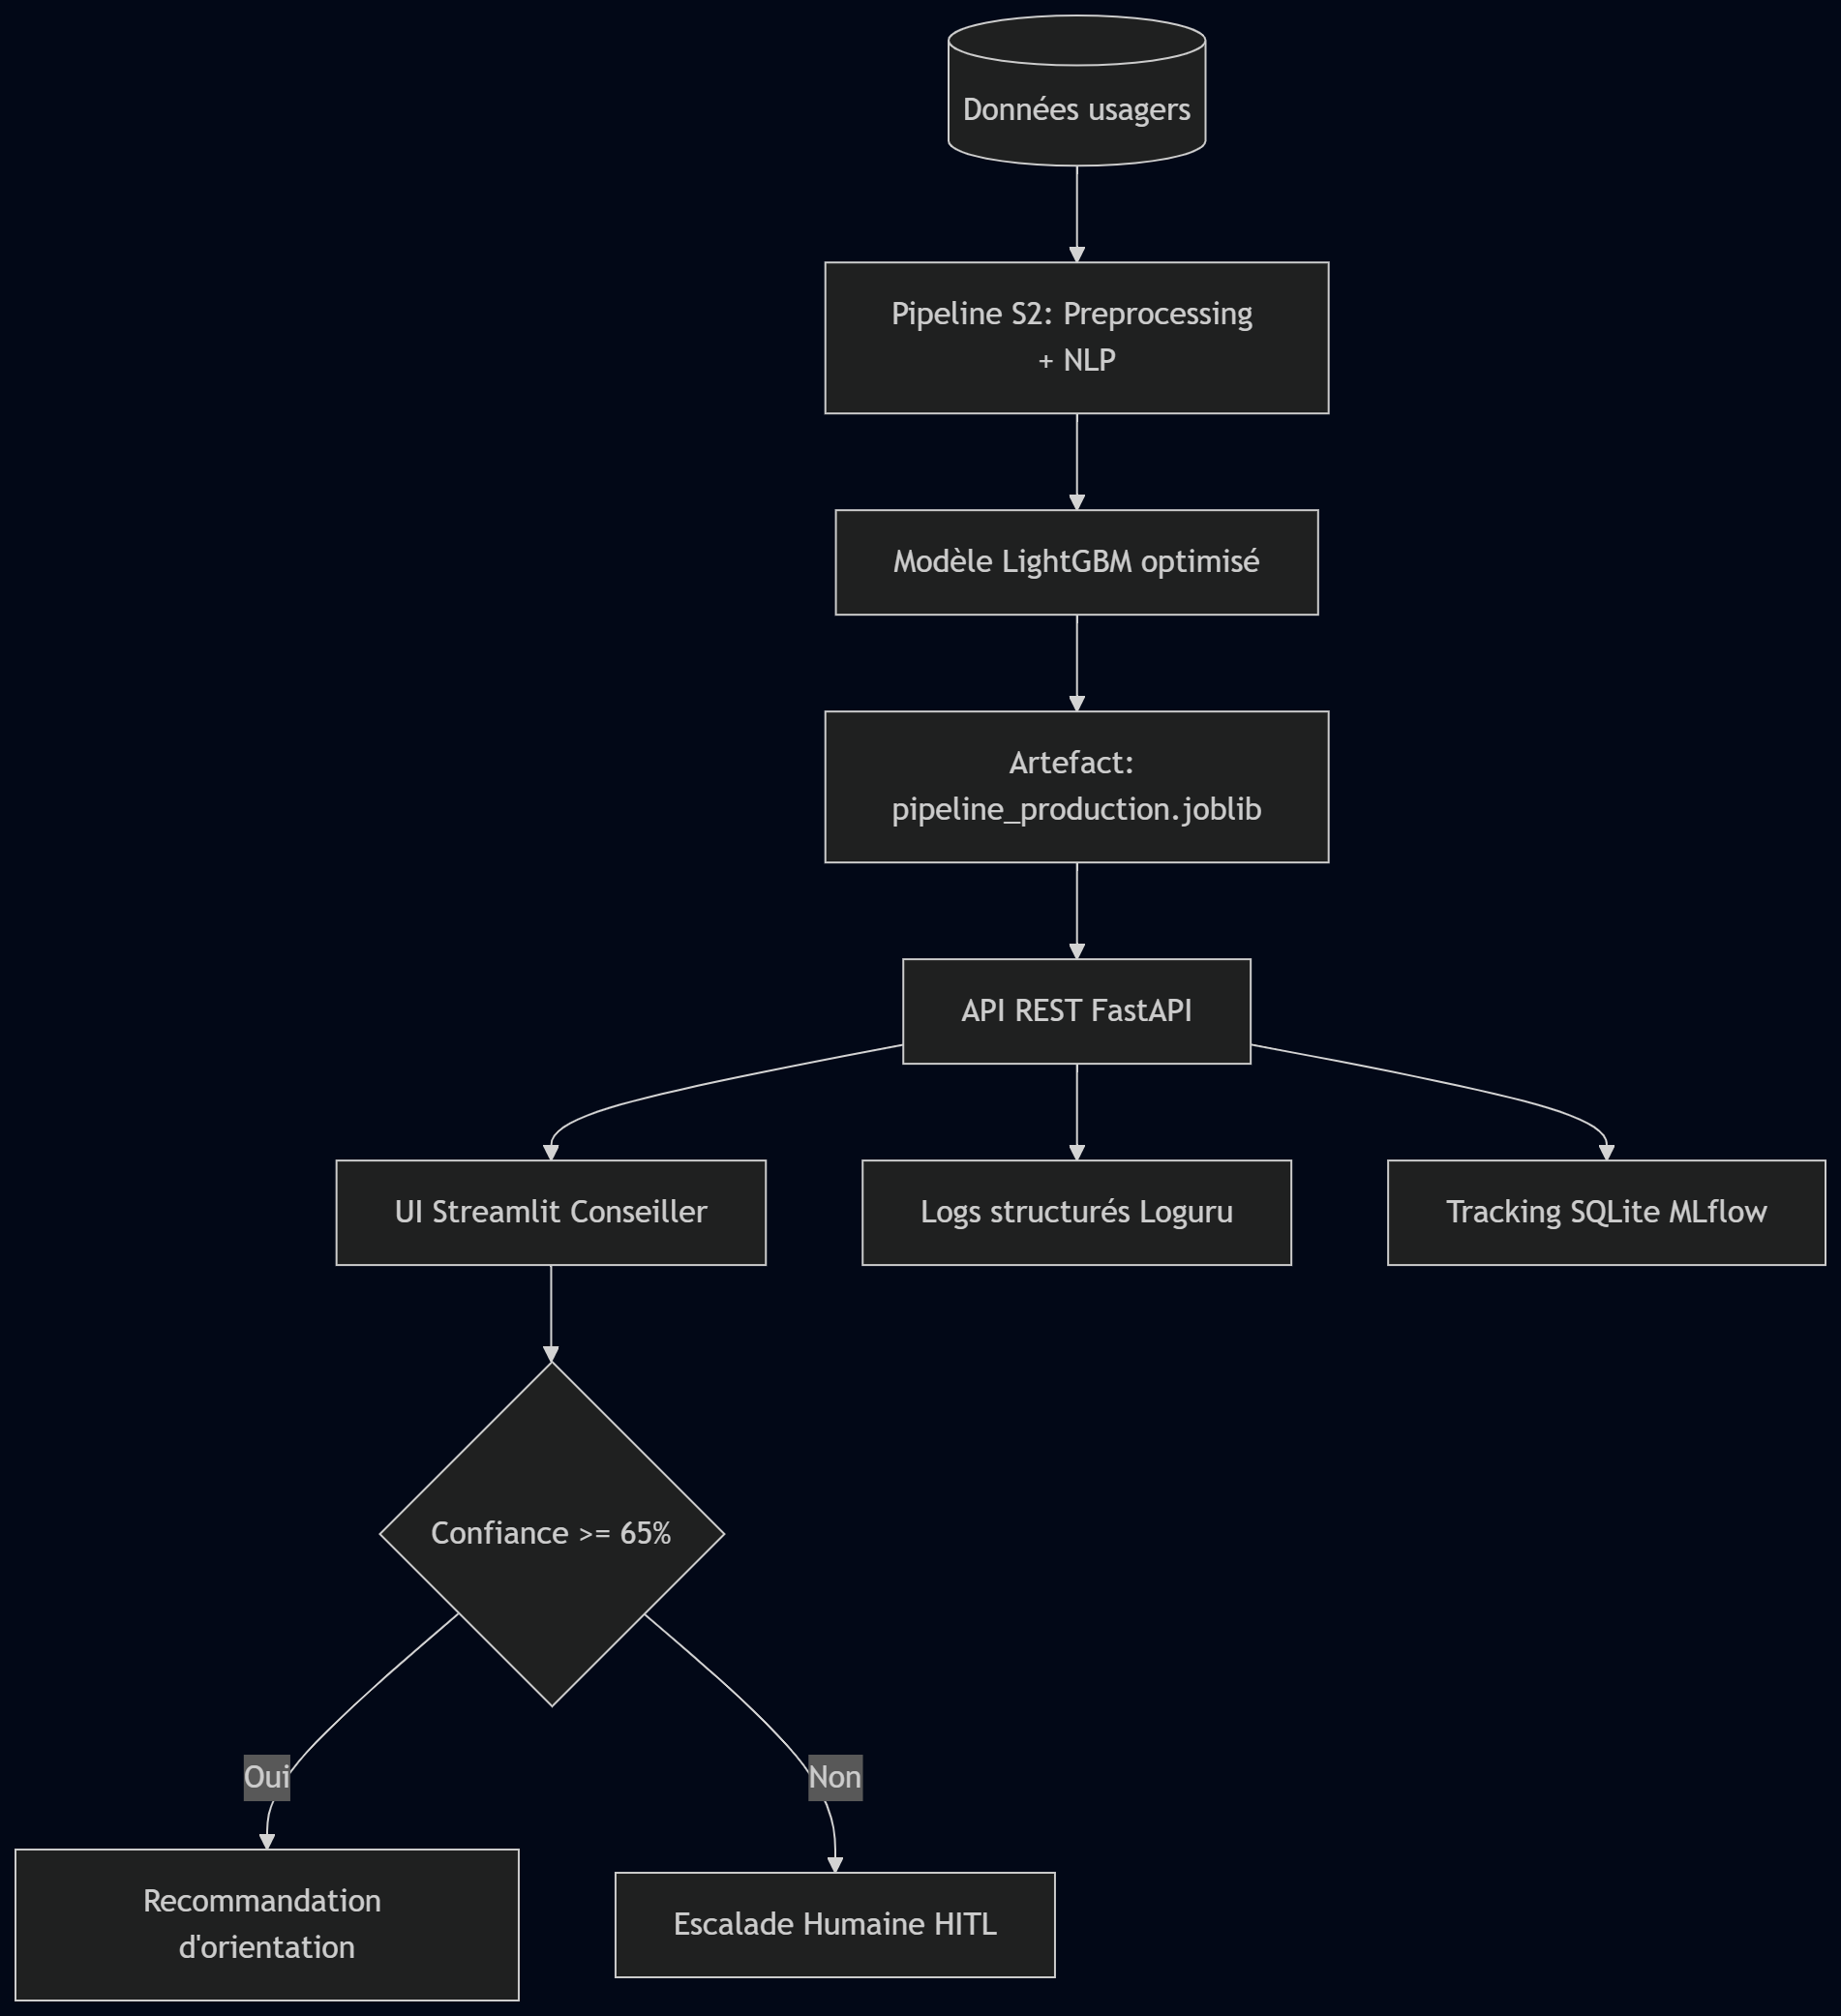

### 8.5 Conteneurisation & CI/CD

- **Docker & Docker-Compose :**
  - Multi-stage build Python 3.12 slim pour une image minimale et sécurisée (< 300 MB).
  - Fichier `docker-compose.yml` orchestrant l'API FastAPI (`port 8000`) et l'UI Streamlit (`port 8501`).
- **Pipeline CI/CD (GitHub Actions) :**
  - `lint` : Vérification du code avec `flake8` / `black`.
  - `test` : Exécution des tests unitaires et d'intégration avec `pytest` (`test_api.py`, `test_pipeline.py`).
  - `build` : Construction et validation des conteneurs Docker lors des commits sur `master`.

### 8.6 📝 Synthèse industrialisation

La pile technique retenue (**FastAPI + Pydantic + Streamlit + MLflow + Docker**) garantit une architecture MLOps légère, robuste, certifiable et immédiatement déployable dans l'infrastructure de France Travail. Grâce au couplage du typage Pydantic, de la validation des données d'entrée et du seuil de confiance à 65%, le service est résilient contre les défaillances et conforme aux préconisations de l'AI Act.


---
## 9. Suivi en production & amélioration continue

### 9.1 Métriques à surveiller

Dans notre architecture cible, nous monitorons trois dimensions clés pour garantir la santé globale de l'IA :

1. **Métriques Système (Disponibles en temps réel via Prometheus/Grafana)** :
   * **Métrique** : Latence p95 (temps de réponse) et Taux d'erreur HTTP.
   * **Pourquoi** : Assure que l'API de prédiction répond suffisamment vite pour ne pas bloquer l'outil du conseiller.
   * **Seuil d'alerte** : Latence > 500 ms (dégradation de l'UX).

2. **Métriques Métiers & Modèle (Accessibles via nos compteurs Prometheus personnalisés)** :
   * **Métrique** : Taux d'escalade (Fallback rate) et Distribution des prédictions.
   * **Pourquoi** : Mesure l'efficacité opérationnelle (combien de dossiers le modèle arrive-t-il à traiter avec confiance ?). Si le modèle rejette soudainement 60% des dossiers (contre **38,8%** mesurés nominalement au seuil de confiance de 65%), c'est une anomalie grave.
   * **Seuil d'alerte** : Dérive relative > 20% du taux de fallback par rapport à la moyenne historique (ex: dépassement persistant de 48%).

3. **Métriques Data & Performance (Nécessite un Batch asynchrone / MLflow)** :
   * **Métrique** : F1-macro (Performance) et PSI - Population Stability Index (Dérive des données).
   * **Comment** : Contrairement aux métriques système, la performance réelle (F1) ne peut être calculée que plusieurs mois plus tard, lorsque nous obtenons la vérité terrain (retour à l'emploi effectif du candidat). Pour anticiper cela, nous calculons quotidiennement le PSI sur les variables d'entrée : si le profil des candidats change (Data Drift), on s'attend à ce que le modèle se trompe.
   * **Seuil d'alerte** : PSI > 0.2 sur les features clés (ex: ROME, diplôme) ou chute de 5 points du F1-macro.


---
## 📎 Annexes
 
### A. Glossaire métier & technique

#### 🏢 Concepts Métiers (Orientation & Emploi)
* **ROME (Répertoire Opérationnel des Métiers et des Emplois)** : Nomenclature standardisée (lettre + 4 chiffres) utilisée en France pour classifier les métiers, les familles professionnelles et les compétences.
* **Frein périphérique** : Obstacle au retour à l'emploi qui n'est pas directement lié aux compétences professionnelles (ex: problèmes de mobilité, de santé, de logement ou de garde d'enfant).
* **Escalade Humaine (Fallback)** : Processus métier déclenché lorsque la confiance de l'IA est trop faible. La décision algorithmique est suspendue et le dossier est confié à l'expertise d'un conseiller humain.
* **Prophétie auto-réalisatrice** : Biais cognitif et statistique où la prédiction de l'IA provoque l'action qui vient ensuite confirmer la prédiction (ex: identifier un chômage long déclenche une aide qui l'évite, faussant l'évaluation future du modèle).

#### 💻 Concepts Techniques (Machine Learning & MLOps)
* **Disparate Impact** : Indicateur statistique d'équité (*Fairness*), issu historiquement du droit du travail américain (règle des 4/5 de l'EEOC). Il mesure le ratio de taux de sélection entre deux groupes (ex: jeunes vs seniors, nationalité). Bien qu'il ne constitue pas une obligation légale chiffrée de l'AI Act européen, il sert de repère pratique pour détecter d'éventuels biais indirects.
* **SHAP (SHapley Additive exPlanations)** : Méthode mathématique issue de la théorie des jeux permettant d'apporter une explicabilité locale et globale. Elle quantifie l'impact exact (positif ou négatif) de chaque variable sur la décision finale.
* **TF-IDF (Term Frequency - Inverse Document Frequency)** : Algorithme de NLP permettant de mesurer l'importance d'un mot dans un document par rapport à un corpus. Il est utilisé ici en alternative légère et explicable aux réseaux de neurones profonds.
* **Data Drift (Dérive des données)** : Dégradation de la performance d'un modèle en production causée par un changement progressif ou brutal du profil des données entrantes par rapport à la base d'entraînement historique.
* **PSI (Population Stability Index)** : Indicateur statistique servant à quantifier ce fameux *Data Drift* en comparant la distribution des données actuelles avec celle d'origine.

### B. Sources & bibliographie

**1. Éthique, Réglementation et Biais Algorithmiques**
* **Loi sur l'Intelligence Artificielle (AI Act)**, Parlement Européen (2024). Directives spécifiques concernant les systèmes d'IA à haut risque, notamment dans les domaines de l'emploi et de l'orientation professionnelle.
* **Datasheets for Datasets**, Timnit Gebru et al. (2018). Méthodologie standardisée pour la documentation et la transparence des jeux de données utilisés en Machine Learning.
* **Fairness and Machine Learning: Limitations and Opportunities**, Solon Barocas, Moritz Hardt, Arvind Narayanan (2019). Concepts fondamentaux sur l'équité algorithmique, l'évaluation des biais et le *Disparate Impact*.

**2. Technique, Modélisation et Explicabilité**
* **A Unified Approach to Interpreting Model Predictions (SHAP)**, Scott M. Lundberg, Su-In Lee (2017). Introduction aux valeurs de Shapley pour l'interprétabilité locale et globale des modèles boîtes noires.
* **LightGBM: A Highly Efficient Gradient Boosting Decision Tree**, Guolin Ke et al. (2017).
* **Scikit-learn: Machine Learning in Python**, Pedregosa et al. (2011).

**3. Industrialisation et MLOps**
* **Hidden Technical Debt in Machine Learning Systems**, D. Sculley et al. (Google, 2015). Principes de base sur l'importance du monitoring, du maintien en condition opérationnelle et de la boucle de rétroaction.
* **Documentation officielle Prometheus & Grafana** pour la mise en place de la télémétrie temps réel.
* **MLflow Documentation** pour le suivi des expérimentations et la gestion du cycle de vie des modèles.


### C. Regards critiques sur les choix de modélisation

Lors de la conception de cette solution d'orientation, plusieurs choix d'ingénierie peuvent paraître contre-intuitifs ou "simples" au premier abord. Voici les justifications éthiques et techniques de deux de ces décisions majeures :

#### Le retrait de l'Âge (Lutte contre le *Disparate Impact*)

Pourquoi retirer l'âge (Scénario 2) alors qu'il est prédictif du chômage longue durée ?
- **Le piège du stéréotype :** L'analyse exploratoire a montré que les seniors (45-65 ans) sont sur-représentés dans la classe "Risque longue durée" (29% contre 9% pour les plus jeunes). Si l'on conserve l'âge, l'algorithme fait un raccourci mathématique "paresseux" : il risque de classer automatiquement un senior en Risque 2, même si son parcours individuel (compétences, dynamisme) est excellent.
- **La conformité à l'AI Act :** Retirer l'âge force le modèle à être aveugle (*Fairness through Blindness*). L'IA est obligée de chercher les véritables freins professionnels (évalués via le texte du conseiller ou l'ancienneté) au lieu d'appliquer une ségrégation statistique basée sur un critère démographique (génération). Cela élimine le risque de discrimination et garantit l'équité algorithmique.

#### L'analyse NLP avec TF-IDF au lieu du Deep Learning (CamemBERT / Embeddings)

Pourquoi se contenter d'une analyse "mot-à-mot" (TF-IDF) plutôt que d'utiliser une analyse sémantique profonde (Deep Learning) ?
- **L'exigence absolue d'Explicabilité :** Un modèle sémantique de type Deep Learning est une "boîte noire". Il est incapable d'expliquer pourquoi il a pris une décision. À l'inverse, avec le TF-IDF couplé à un arbre de décision, la prédiction est 100% transparente. On peut justifier que le modèle a alerté sur un profil parce qu'il a détecté le mot-clé "dépression" ou "frein périphérique". Dans un service public d'orientation, l'explicabilité est non négociable.
- **La nature des données :** Le jeu de données contient des notes de conseillers (synthèses courtes, stéréotypées, truffées de jargon métier). Le Deep Learning brille sur de la littérature complexe, mais sur ces synthèses de guichet, une approche sémantique lourde apporterait peu de valeur ajoutée et risquerait de sur-apprendre (*overfitting*) sur notre petit volume de données (2500 lignes).
- **Faisabilité opérationnelle (Green IT & Temps réel) :** Le TF-IDF est extrêmement léger. Il s'exécute en une fraction de milliseconde sans nécessiter de serveurs GPU coûteux et énergivores. C'est l'architecture parfaite (Principe KISS) pour un outil d'aide à la décision au guichet.



#### La gestion de la Cardinalité et du Sur-apprentissage (Petit volume de données)

Pourquoi le modèle ne fait-il pas de sur-apprentissage (*overfitting*) sur des variables très éparpillées comme le code commune ou le code métier, alors que nous n'avons que 2500 lignes ?
- **Le risque mathématique (Malédiction de la dimensionnalité) :** Avec 2500 lignes et plus de 2000 codes communes INSEE différents, utiliser la commune brute forcerait le modèle à apprendre "par cœur" des individus isolés, détruisant sa capacité à généraliser sur de nouveaux profils.
- **La parade par le Feature Engineering (Ingénierie des caractéristiques) :** Pour contrer ce risque, nous avons volontairement détruit la précision chirurgicale de la donnée pour en extraire des macro-tendances. Le `code_insee_commune` a été tronqué pour ne conserver que le `département` (réduisant la cardinalité de >2000 à ~100). De même, le `code_rome_vise` a été réduit à sa première lettre (`famille_rome`). 
- **Le bridage de l'algorithme (Régularisation) :** Lors de l'optimisation (Partie 5), des hyperparamètres comme `min_child_samples` (LightGBM) ont été fixés à 20 ou 50. Cela interdit mathématiquement à l'algorithme de créer une "règle de décision" s'il n'a pas au moins 20 profils sous la main. Il est donc impossible pour l'IA d'isoler un usager unique dans un département précis : elle est contrainte de chercher des motifs globaux.


#### Ouverture et Perspectives : La volumétrie des données

Toutes ces stratégies de contournement (réduction de dimensionnalité, TF-IDF basique, forte régularisation) ont été dictées par la taille extrêmement restreinte de notre échantillon (2500 lignes). Pour un service public national (France Travail / Pôle Emploi) qui brasse des millions de dossiers par an, ce jeu de données s'apparente à un *Proof of Concept* (PoC).

**Que permettrait le passage à l'échelle (ex: 500 000 dossiers) ?**
- **Exploiter la granularité locale :** Nous pourrions abandonner le regroupement par `département` et utiliser directement le `code_insee_commune` brut. Le modèle aurait alors suffisamment d'exemples statistiques par commune pour modéliser le bassin d'emploi ultra-local sans faire de sur-apprentissage.
- **Réévaluer le Deep Learning (NLP) :** Avec un demi-million de synthèses textuelles, l'entraînement d'un modèle sémantique de type CamemBERT ou d'Embeddings fins prendrait tout son sens et permettrait de capter les nuances linguistiques (négations, euphémismes des conseillers). Il faudrait néanmoins conserver une architecture "explicable" via des surcouches techniques (comme LIME ou SHAP) pour rester en conformité avec l'AI Act.

*En conclusion : le modèle actuel est robuste pour valider la faisabilité (MVP), mais son architecture devra évoluer face à un passage à l'échelle (Scale-up).*


#### Le Biais d'Automatisation et la conception de l'Interface (Human-In-The-Loop)

Bien que l'IA soit conçue comme une simple "aide à la décision", la réalité ergonomique du terrain se heurte au **biais d'automatisation** : la tendance psychologique humaine à faire une confiance aveugle à la machine.
Si un conseiller fatigué, gérant un flux massif de dossiers, voit l'IA afficher en vert "Retour Rapide", il risque de ne plus creuser l'entretien et de valider sans esprit critique. L'IA cesse d'être un assistant pour devenir, par effet de bord, le véritable décideur.

**Piste de mitigation UX/UI :** Dans le design de l'application finale, l'interface ne devrait pas proposer sa réponse si l'indice de confiance est insuffisant.


### D. Journal de bord
